In [1]:
# Imports
import os, sys, gc, pathlib, warnings
import numpy as np
import pandas as pd
import tensorflow as tf
import psutil
import pathlib
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import collections
import re
import shutil
import zipfile
import random
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm


from sklearn.model_selection import GroupShuffleSplit
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, log_loss)
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
# Célula 1: Configuração do Ambiente e Inspeção do Dataset 
warnings.filterwarnings('ignore')

# Diretório de saída para salvar os modelos treinados 
RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"✓ Diretório de resultados pronto: {RESULTS_DIR}")

# Versões do Python e bibliotecas principais 
print(f"\n Informações de Versão")
print(f"  Python      : {sys.version.split()[0]}")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  NumPy       : {np.__version__}")
print(f"  Pandas      : {pd.__version__}")

# Informações de Memória RAM 
ram = psutil.virtual_memory()
print(f"\n Informações de Memória RAM")
print(f"  RAM Total   : {ram.total / 1e9:.1f} GB")
print(f"  Disponível  : {ram.available / 1e9:.1f} GB")
print(f"  Em uso      : {ram.percent:.1f}%")

# Informações da GPU 
print(f"\n Informações da GPU")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f"  GPU Encontrada   : {gpu.name}")
    # Permitir crescimento de memória — evita que o TensorFlow trave toda a VRAM de uma vez
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"  Crescimento de memória habilitado ✓")
else:
    print("  Nenhuma GPU encontrada — o código rodará na CPU")

# Configuração do Diretório do Dataset 
# Aponta para onde as pastas 'jpeg' e 'csv' estão salvas
INPUT_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")

print(f"\n── Entradas principais no diretório {INPUT_ROOT} ──")
if not INPUT_ROOT.exists():
    print(f"  ⚠ O diretório {INPUT_ROOT} não foi encontrado. Verifique o caminho.")
else:
    entries = sorted(INPUT_ROOT.iterdir())
    if not entries:
        print("  ⚠ O diretório do dataset está vazio.")
    else:
        for e in entries:
            kind = "[DIRETÓRIO]" if e.is_dir() else "[ARQUIVO]"
            print(f"  {kind} {e.name}")

✓ Diretório de resultados pronto: C:\Users\analice\Documents\TCC\resultados\efficientnet

 Informações de Versão
  Python      : 3.10.11
  TensorFlow  : 2.21.0
  NumPy       : 2.2.6
  Pandas      : 2.3.3

 Informações de Memória RAM
  RAM Total   : 14.9 GB
  Disponível  : 4.9 GB
  Em uso      : 67.5%

 Informações da GPU
  Nenhuma GPU encontrada — o código rodará na CPU

── Entradas principais no diretório C:\Users\analice\Documents\TCC\dataset ──
  [DIRETÓRIO] csv
  [DIRETÓRIO] jpeg


In [3]:
# Célula 2: Inspeção da Árvore do Dataset

# Localizar raiz do dataset 
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")
print(f"✓ Raiz do dataset: {DATASET_ROOT}\n")

# Função recursiva para imprimir a árvore (máx 3 níveis, máx 8 entradas por pasta)
IMAGE_EXTS  = {'.jpg', '.jpeg', '.png', '.dcm', '.tif', '.tiff', '.bmp'}
META_EXTS   = {'.csv', '.json', '.txt', '.xlsx', '.tsv'}

image_counter = collections.Counter()    # ext -> contagem (global)
meta_files    = []                       # todos os caminhos de arquivos de metadados encontrados
MAX_DEPTH        = 3
MAX_ENTRIES_SHOW = 8   # limite de exibição por pasta

def inspect_tree(path: pathlib.Path, depth: int = 0):
    if depth > MAX_DEPTH:
        return
    try:
        entries = sorted(path.iterdir())
    except PermissionError:
        print("  " * depth + "  [permissão negada]")
        return

    shown = 0
    for e in entries:
        if e.is_dir():
            print("  " * depth + f"📁 {e.name}/")
            inspect_tree(e, depth + 1)

        elif e.is_file():
            ext = e.suffix.lower()
            size_mb = e.stat().st_size / 1e6

            # Sempre rastrear metadados/imagens — mesmo que a impressão visual seja interrompida
            if ext in IMAGE_EXTS:
                image_counter[ext] += 1
            if ext in META_EXTS:
                meta_files.append(e)

            if shown < MAX_ENTRIES_SHOW:
                tag = "📄" if ext not in IMAGE_EXTS else "🖼️ "
                print("  " * depth + f"  {tag} {e.name}  ({size_mb:.2f} MB)")
                shown += 1
            elif shown == MAX_ENTRIES_SHOW:
                # Contar os arquivos restantes nesta pasta sem imprimir cada um na tela
                remaining = sum(1 for x in entries if x.is_file()) - MAX_ENTRIES_SHOW
                if remaining > 0:
                    print("  " * depth + f"  ... e mais {remaining} arquivos")
                shown += 1   # garantir que os "..." apareçam apenas uma vez por pasta

inspect_tree(DATASET_ROOT)

# Resumo dos arquivos de imagem
print("\n Contagem de arquivos de imagem (por extensão)")
if image_counter:
    for ext, cnt in sorted(image_counter.items()):
        print(f"  {ext:<8} : {cnt:,} arquivos")
else:
    print("  ⚠ Nenhum arquivo de imagem encontrado na raiz do dataset")

# Resumo dos arquivos de metadados 
print("\n Arquivos de metadados / CSV encontrados")
if meta_files:
    for mf in sorted(meta_files):
        rel = mf.relative_to(DATASET_ROOT)
        size_mb = mf.stat().st_size / 1e6
        print(f"  📋 {rel}  ({size_mb:.2f} MB)")
else:
    print("  ⚠ Nenhum arquivo de metadados CSV/JSON/TXT encontrado")

✓ Raiz do dataset: C:\Users\analice\Documents\TCC\dataset

📁 csv/
    📄 calc_case_description_test_set.csv  (0.19 MB)
    📄 calc_case_description_train_set.csv  (0.93 MB)
    📄 dicom_info.csv  (6.35 MB)
    📄 mass_case_description_test_set.csv  (0.22 MB)
    📄 mass_case_description_train_set.csv  (0.77 MB)
    📄 meta.csv  (1.18 MB)
📁 jpeg/
  📁 1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132/
      🖼️  1-263.jpg  (0.02 MB)
      🖼️  2-241.jpg  (0.16 MB)
  📁 1.3.6.1.4.1.9590.100.1.2.100131208110604806117271735422083351547/
      🖼️  1-126.jpg  (2.49 MB)
  📁 1.3.6.1.4.1.9590.100.1.2.100522099512256189513864912954167862869/
      🖼️  1-231.jpg  (3.17 MB)
  📁 1.3.6.1.4.1.9590.100.1.2.100522676511025180541602449080267145647/
      🖼️  1-111.jpg  (1.71 MB)
  📁 1.3.6.1.4.1.9590.100.1.2.10055294210766234140934516480682841962/
      🖼️  1-031.jpg  (0.00 MB)
      🖼️  2-011.jpg  (0.27 MB)
  📁 1.3.6.1.4.1.9590.100.1.2.100579676611077714807988832023693299884/
      🖼️  1-108.jpg  (

In [4]:
# Célula 3: Inspeção de Metadados 

# Substituído pelo seu diretório local
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")
CSV_DIR      = DATASET_ROOT / "csv"

csv_files = sorted(CSV_DIR.glob("*.csv"))
print(f"✓ Encontrados {len(csv_files)} arquivos CSV\n")

# Dicas (palavras-chave) para tentar achar colunas de classificação e caminhos de imagens
LABEL_HINTS = ['pathology', 'label', 'class', 'type', 'abnormality', 'finding']
PATH_HINTS  = ['path', 'file', 'image', 'img', 'cropped', 'roi', 'jpeg']

best_file  = None
best_score = -1

for csv_path in csv_files:
    print("=" * 65)
    print(f"📋 {csv_path.name}")
    try:
        df    = pd.read_csv(csv_path)
        print(f"   Formato             : {df.shape[0]:,} linhas x {df.shape[1]} colunas")
        print(f"   Colunas             : {list(df.columns)}")
        print(f"   Primeiras 3 linhas  :")
        print(df.head(3).to_string(max_colwidth=35))

        cols_lower    = [c.lower() for c in df.columns]
        label_matches = [c for c in cols_lower if any(h in c for h in LABEL_HINTS)]
        path_matches  = [c for c in cols_lower if any(h in c for h in PATH_HINTS)]
        score         = len(label_matches) * 2 + len(path_matches)

        print(f"\n Colunas (rótulo)  : {label_matches}")
        print(f"   Colunas (caminho) : {path_matches}")
        print(f"   Pontuação         : {score}")

        if score > best_score:
            best_score = score
            best_file  = csv_path.name

        del df

    except Exception as ex:
        print(f"   ⚠ Não foi possível ler: {ex}")
    print()

print("=" * 65)
print(f" Arquivo mais útil (heurística) : {best_file}  (pontuação={best_score})")

✓ Encontrados 6 arquivos CSV

📋 calc_case_description_test_set.csv
   Formato             : 326 linhas x 14 colunas
   Colunas             : ['patient_id', 'breast density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'calc type', 'calc distribution', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
   Primeiras 3 linhas  :
  patient_id  breast density left or right breast image view  abnormality id abnormality type             calc type calc distribution  assessment                pathology  subtlety                     image file path             cropped image file path                  ROI mask file path
0    P_00038               2                 LEFT         CC               1    calcification  PUNCTATE-PLEOMORPHIC         CLUSTERED           4                   BENIGN         2  Calc-Test_P_00038_LEFT_CC/1.3.6...  Calc-Test_P_00038_LEFT_CC_1/1.3...  Calc-Test_P_00038_LEFT_CC_1/1.3...
1    P

In [5]:
# Célula 4: Construir & Salvar Índice de Arquivos Verificado 
# Totalmente independente — seguro para rodar após reiniciar o kernel

# Caminhos locais configurados
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")
CSV_DIR      = DATASET_ROOT / "csv"
RESULTS_DIR  = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Sempre recriar o diretório de saída primeiro 
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"✓ Diretório de resultados pronto : {RESULTS_DIR}")

# Passo 1: Carregar todos os 4 CSVs de casos
print("\n Passo 1: Carregando CSVs de casos")
frames = []
for fname, lesion_label in [
    ("calc_case_description_train_set.csv", "calcification"),
    ("calc_case_description_test_set.csv",  "calcification"),
    ("mass_case_description_train_set.csv", "mass"),
    ("mass_case_description_test_set.csv",  "mass"),
]:
    df = pd.read_csv(CSV_DIR / fname)
    # Padronizando nomes das colunas
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    df["lesion_type"] = lesion_label
    frames.append(df)
    print(f"  ✓ {fname:45} {len(df):>5} linhas")

combined = pd.concat(frames, ignore_index=True)
print(f"  Combinado : {len(combined):,} linhas")

# Passo 2: Carregar dicom_info, manter apenas imagens recortadas (cropped) 
print("\n Passo 2: Carregando dicom_info (apenas imagens cropped)")
dicom = pd.read_csv(CSV_DIR / "dicom_info.csv")
dicom.columns = [c.strip().lower().replace(" ", "_") for c in dicom.columns]
cropped = dicom[
    dicom["seriesdescription"].str.lower().str.contains("cropped", na=False)
].copy()
print(f"  Linhas cropped : {len(cropped):,}")

# Passo 3: Resolver caminhos absolutos JPEG (remover prefixo antigo)
print("\n Passo 3: Resolvendo caminhos absolutos JPEG")
PREFIX = "CBIS-DDSM/"

def make_abs_jpeg(raw):
    try:
        p = str(raw).strip()
        if p.startswith(PREFIX):
            p = p[len(PREFIX):]
        abs_p = DATASET_ROOT / p
        return str(abs_p) if abs_p.exists() else None
    except:
        return None

cropped = cropped.copy()
cropped["abs_jpeg"] = cropped["image_path"].apply(make_abs_jpeg)
found = cropped["abs_jpeg"].notna().sum()
print(f"  Arquivos JPEG verificados : {found:,} / {len(cropped):,}")

# Passo 4: Construir chaves de correspondência 
print("\n Passo 4: Construindo chaves de correspondência")
def get_pid(s):
    m = re.search(r'(P_\d+)', str(s)); return m.group(1) if m else None
def get_view(s):
    m = re.search(r'_(CC|MLO)_', str(s)); return m.group(1) if m else None
def get_side(s):
    m = re.search(r'_(LEFT|RIGHT)_', str(s)); return m.group(1) if m else None

cropped["pid_key"]  = cropped["patientid"].apply(get_pid)
cropped["view_key"] = cropped["patientid"].apply(get_view)
cropped["side_key"] = cropped["patientid"].apply(get_side)

combined["pid_key"]  = combined["patient_id"].apply(get_pid)
combined["view_key"] = combined["image_view"].str.strip().str.upper()
combined["side_key"] = combined["left_or_right_breast"].str.strip().str.upper()

# Passo 5: Mesclar (Merge) 
print("\n Passo 5: Mesclando (Merge)")
dicom_slim = (
    cropped[["pid_key", "view_key", "side_key", "abs_jpeg"]]
    .dropna()
    .drop_duplicates(subset=["pid_key", "view_key", "side_key"])
)
merged = combined.merge(
    dicom_slim, on=["pid_key", "view_key", "side_key"], how="left"
)
print(f"  Correspondentes (Matched)       : {merged['abs_jpeg'].notna().sum():,}")
print(f"  Sem correspondência (Unmatched) : {merged['abs_jpeg'].isna().sum():,}")

# Passo 6: Construir & salvar índice final
print("\n Passo 6: Construindo índice final")
index_df = merged[merged["abs_jpeg"].notna()].copy()
index_df = index_df.rename(columns={"abs_jpeg": "image_path"})

index_df = index_df[[
    "patient_id", "lesion_type", "pathology",
    "image_path", "left_or_right_breast", "image_view"
]].reset_index(drop=True)

# Mapeando calcificaçõa para 0 e massa para 1
index_df["label"] = index_df["lesion_type"].map({"calcification": 0, "mass": 1})

print(f"  Formato (Shape) : {index_df.shape}")
print(f"  Classes:\n{index_df['lesion_type'].value_counts().to_string()}")

out_path = RESULTS_DIR / "indice_arquivos.csv"
index_df.to_csv(out_path, index=False)
print(f"\n Salvo → {out_path}  ({len(index_df):,} linhas)")

✓ Diretório de resultados pronto : C:\Users\analice\Documents\TCC\resultados\efficientnet

 Passo 1: Carregando CSVs de casos
  ✓ calc_case_description_train_set.csv            1546 linhas
  ✓ calc_case_description_test_set.csv              326 linhas
  ✓ mass_case_description_train_set.csv            1318 linhas
  ✓ mass_case_description_test_set.csv              378 linhas
  Combinado : 3,568 linhas

 Passo 2: Carregando dicom_info (apenas imagens cropped)
  Linhas cropped : 3,567

 Passo 3: Resolvendo caminhos absolutos JPEG
  Arquivos JPEG verificados : 3,567 / 3,567

 Passo 4: Construindo chaves de correspondência

 Passo 5: Mesclando (Merge)
  Correspondentes (Matched)       : 3,568
  Sem correspondência (Unmatched) : 0

 Passo 6: Construindo índice final
  Formato (Shape) : (3568, 7)
  Classes:
lesion_type
calcification    1872
mass             1696

 Salvo → C:\Users\analice\Documents\TCC\resultados\efficientnet\indice_arquivos.csv  (3,568 linhas)


In [6]:
# Célula 5: Construir Índice de Arquivos Verificado 

# Caminhos locais configurados 
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")
CSV_DIR      = DATASET_ROOT / "csv"
JPEG_DIR     = DATASET_ROOT / "jpeg"
RESULTS_DIR  = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Garantindo que a pasta de resultados exista (boa prática no local)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Passo 1: Carregar todos os 4 CSVs de casos
print(" Passo 1: Carregando CSVs de casos ")
frames = []
for fname, lesion_label in [
    ("calc_case_description_train_set.csv",  "calcification"),
    ("calc_case_description_test_set.csv",   "calcification"),
    ("mass_case_description_train_set.csv",  "mass"),
    ("mass_case_description_test_set.csv",   "mass"),
]:
    df = pd.read_csv(CSV_DIR / fname)
    df["lesion_type"] = lesion_label
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    frames.append(df)
    print(f"  ✓ {fname:<45}  {len(df):>5} linhas")

combined = pd.concat(frames, ignore_index=True)
print(f"  Combinado : {len(combined):,} linhas")

# Passo 2: Carregar dicom_info, manter apenas imagens recortadas (cropped) 
print("\n Passo 2: Carregando dicom_info (apenas linhas cropped) ")
dicom = pd.read_csv(CSV_DIR / "dicom_info.csv")
dicom.columns = [c.strip().lower().replace(" ", "_") for c in dicom.columns]
cropped = dicom[
    dicom["seriesdescription"].str.lower().str.contains("cropped", na=False)
].copy()
print(f"  Linhas cropped no dicom_info : {len(cropped):,}")

# Passo 3: Construir caminho absoluto jpeg a partir do image_path do dicom 
# image_path = "CBIS-DDSM/jpeg/<UID>/1-xxx.jpg"
# Caminho real = DATASET_ROOT / "jpeg" / <UID> / "1-xxx.jpg"
print("\n Passo 3: Resolvendo caminhos absolutos JPEG")
def make_abs_jpeg(raw_image_path):
    """
    raw_image_path : 'CBIS-DDSM/jpeg/<UID>/nome_do_arquivo.jpg'
    Remove o prefixo 'CBIS-DDSM/jpeg/' e resolve dentro de JPEG_DIR.
    """
    try:
        # Usa PurePosixPath para lidar com as barras '/' do CSV original de forma segura
        p     = pathlib.PurePosixPath(raw_image_path.strip())
        # partes: ('CBIS-DDSM', 'jpeg', '<UID>', 'nome_do_arquivo.jpg')
        uid   = p.parts[-2]
        fname = p.parts[-1]
        abs_p = JPEG_DIR / uid / fname
        return str(abs_p) if abs_p.exists() else None
    except Exception:
        return None

cropped["abs_jpeg"] = cropped["image_path"].apply(make_abs_jpeg)
found_jpeg = cropped["abs_jpeg"].notna().sum()
print(f"  Arquivos JPEG verificados encontrados : {found_jpeg:,} / {len(cropped):,}")

# Passo 4: Construir chave de correspondência a partir do patientid 
# patientid no dicom é parecido com: "Calc-Training_P_00005_RIGHT_CC_1"
# patient_id no CSV de casos é: "P_00005"
# Extrair P_XXXXX de ambos os lados para usar como chave de união (join).
print("\n Passo 4: Construindo chaves de correspondência")


def extract_pid(s):
    m = re.search(r'(P_\d+)', str(s))
    return m.group(1) if m else None

def extract_view(s):
    """Extrair CC ou MLO da string patientid."""
    m = re.search(r'_(CC|MLO)_', str(s))
    return m.group(1) if m else None

def extract_side(s):
    """Extrair LEFT (Esquerda) ou RIGHT (Direita) da string patientid."""
    m = re.search(r'_(LEFT|RIGHT)_', str(s))
    return m.group(1) if m else None

cropped["pid_key"]  = cropped["patientid"].apply(extract_pid)
cropped["view_key"] = cropped["patientid"].apply(extract_view)
cropped["side_key"] = cropped["patientid"].apply(extract_side)

combined["pid_key"]  = combined["patient_id"].apply(extract_pid)
combined["view_key"] = combined["image_view"].str.strip().str.upper()
combined["side_key"] = combined["left_or_right_breast"].str.strip().str.upper()

print(f"  Exemplos de chaves do dicom (pid/view/side):")
print(cropped[["patientid","pid_key","view_key","side_key"]].head(4).to_string())

print(f"\n  Exemplos de chaves de casos (pid/view/side):")
print(combined[["patient_id","pid_key","view_key","side_key"]].head(4).to_string())

# Passo 5: Mesclar usando (pid_key, view_key, side_key) 
print("\n Passo 5: Mesclando por paciente / vista / lado ")

# Manter apenas o que precisamos do dicom cropped
dicom_slim = cropped[["pid_key","view_key","side_key","abs_jpeg"]].dropna()

# Pode haver múltiplos jpegs cropped por paciente/vista/lado (id de anormalidade)
# Manter a primeira correspondência por chave — suficiente para este protótipo
dicom_slim = dicom_slim.drop_duplicates(subset=["pid_key","view_key","side_key"])

merged = combined.merge(
    dicom_slim,
    on=["pid_key","view_key","side_key"],
    how="left"
)

print(f"  Linhas mescladas (Merged)        : {len(merged):,}")
print(f"  Correspondentes (jpeg encontrado): {merged['abs_jpeg'].notna().sum():,}")
print(f"  Sem correspondência (Unmatched)  : {merged['abs_jpeg'].isna().sum():,}")

# Passo 6: Construir índice final limpo 
print("\n Passo 6: Construindo índice final limpo ")
index_df = merged[merged["abs_jpeg"].notna()].copy()
index_df = index_df.rename(columns={"abs_jpeg": "image_path"})

index_df = index_df[[
    "patient_id", "lesion_type", "pathology",
    "image_path", "left_or_right_breast", "image_view"
]].reset_index(drop=True)

index_df["label"] = index_df["lesion_type"].map({"calcification": 0, "mass": 1})

print(f"  Formato final : {index_df.shape}")

print(f"\n  Contagem de classes:")
print(index_df["lesion_type"].value_counts().to_string())

print(f"\n  Contagem de patologias:")
print(index_df["pathology"].value_counts().to_string())

print(f"\n  Linhas de exemplo:")
print(index_df.head(4).to_string())

# Verificação rápida de sanidade — verificar se os 3 primeiros caminhos realmente existem
print(f"\n  Verificação de existência de caminho (primeiros 3):")
for p in index_df["image_path"].head(3):
    print(f"    {'✓' if pathlib.Path(p).exists() else '✗'}  {p}")

# Passo 7: Salvar 
out_path = RESULTS_DIR / "indice_arquivos.csv"
index_df.to_csv(out_path, index=False)
print(f"\n ✓ Salvo → {out_path}  ({len(index_df):,} linhas)")

 Passo 1: Carregando CSVs de casos 
  ✓ calc_case_description_train_set.csv             1546 linhas
  ✓ calc_case_description_test_set.csv               326 linhas
  ✓ mass_case_description_train_set.csv             1318 linhas
  ✓ mass_case_description_test_set.csv               378 linhas
  Combinado : 3,568 linhas

 Passo 2: Carregando dicom_info (apenas linhas cropped) 
  Linhas cropped no dicom_info : 3,567

 Passo 3: Resolvendo caminhos absolutos JPEG
  Arquivos JPEG verificados encontrados : 3,567 / 3,567

 Passo 4: Construindo chaves de correspondência
  Exemplos de chaves do dicom (pid/view/side):
                           patientid  pid_key view_key side_key
0  Mass-Training_P_01265_RIGHT_MLO_1  P_01265      MLO    RIGHT
3        Calc-Test_P_00562_LEFT_CC_2  P_00562       CC     LEFT
6   Calc-Training_P_00181_RIGHT_CC_1  P_00181       CC    RIGHT
7    Calc-Training_P_01015_LEFT_CC_1  P_01015       CC     LEFT

  Exemplos de chaves de casos (pid/view/side):
  patient_id  pid_

In [7]:
# Célula 6: Divisão Treino / Validação / Teste por Paciente

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

# Carregar índice verificado da etapa anterior 
index_df = pd.read_csv(RESULTS_DIR / "indice_arquivos.csv")
print(f"Carregado : {len(index_df):,} linhas")
print(f"Pacientes : {index_df['patient_id'].nunique():,} únicos")
print(f"Classes   : {index_df['label'].value_counts().to_dict()}  (0=calc 1=mass)")

# Estratégia de Divisão 
# patient_id ESTÁ disponível → usar GroupShuffleSplit para que cada linha pertencente
# a um paciente sempre caia em exatamente uma partição (sem vazamento de dados).
print("\n  Estratégia de divisão: por paciente (GroupShuffleSplit no patient_id) ✓")

# Passo 1: Separar 15% dos pacientes para teste
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tv_idx, test_idx = next(gss1.split(index_df, groups=index_df["patient_id"]))

df_trainval = index_df.iloc[tv_idx].copy()
test_df     = index_df.iloc[test_idx].copy()

# Passo 2: Dividir o restante → ~75% treino / ~10% validação (do total)
# val_size relativo ao trainval = 0.10 / 0.85 ≈ 0.118
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.118, random_state=SEED)
tr_idx, val_idx = next(gss2.split(df_trainval, groups=df_trainval["patient_id"]))

train_df = df_trainval.iloc[tr_idx].copy()
val_df   = df_trainval.iloc[val_idx].copy()

# Imprimir tamanhos das divisões e contagem de classes 
print(f"\n Tamanhos das Divisões & Balanceamento de Classes")
for name, df in [("Treino", train_df), ("Valid.", val_df), ("Teste", test_df)]:
    lc  = df["label"].value_counts().to_dict()
    pct = len(df) / len(index_df) * 100
    print(f"  {name:<6}: {len(df):>5} linhas ({pct:4.1f}%) | "
          f"{df['patient_id'].nunique():>4} pacientes | "
          f"calc={lc.get(0,0):>4}  mass={lc.get(1,0):>4}")

# Verificação de sobreposição de pacientes — todos devem ser 0 
print(f"\n Verificação de sobreposição de pacientes (todos devem ser 0)")
tr_pts  = set(train_df["patient_id"])
val_pts = set(val_df["patient_id"])
te_pts  = set(test_df["patient_id"])

for a_name, a, b_name, b in [
    ("Treino", tr_pts, "Valid.", val_pts),
    ("Treino", tr_pts, "Teste",  te_pts),
    ("Valid.", val_pts, "Teste",  te_pts),
]:
    n = len(a & b)
    print(f"  {a_name} ∩ {b_name:6}: {n} pacientes compartilhados  {'✓' if n == 0 else '✗ VAZAMENTO!'}")

# Salvar (Apenas caminhos CSV — zero dados de pixel na RAM) 
train_df.to_csv(RESULTS_DIR / "train_df.csv", index=False)
val_df.to_csv  (RESULTS_DIR / "val_df.csv",   index=False)
test_df.to_csv (RESULTS_DIR / "test_df.csv",  index=False)

print(f"\n✓ Salvos train_df.csv / val_df.csv / test_df.csv → {RESULTS_DIR}")
print("✓ Célula 6 concluída — pode enviar a próxima parte.")

Carregado : 3,568 linhas
Pacientes : 1,566 únicos
Classes   : {0: 1872, 1: 1696}  (0=calc 1=mass)

  Estratégia de divisão: por paciente (GroupShuffleSplit no patient_id) ✓

 Tamanhos das Divisões & Balanceamento de Classes
  Treino:  2665 linhas (74.7%) | 1173 pacientes | calc=1404  mass=1261
  Valid.:   365 linhas (10.2%) |  158 pacientes | calc= 198  mass= 167
  Teste :   538 linhas (15.1%) |  235 pacientes | calc= 270  mass= 268

 Verificação de sobreposição de pacientes (todos devem ser 0)
  Treino ∩ Valid.: 0 pacientes compartilhados  ✓
  Treino ∩ Teste : 0 pacientes compartilhados  ✓
  Valid. ∩ Teste : 0 pacientes compartilhados  ✓

✓ Salvos train_df.csv / val_df.csv / test_df.csv → C:\Users\analice\Documents\TCC\resultados\efficientnet
✓ Célula 6 concluída — pode enviar a próxima parte.


In [8]:
# Célula 7: Pipelines tf.data Seguros para Memória
RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Configuração 
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32          
AUTOTUNE   = tf.data.AUTOTUNE

print(f"  Tamanho da imagem : {IMG_SIZE}")
print(f"  Tamanho do lote   : {BATCH_SIZE}")
print(f"  Cache             : DESATIVADO (apenas leituras lazy/preguiçosas do disco)")

# Carregar CSVs de divisão
train_df = pd.read_csv(RESULTS_DIR / "train_df.csv")
val_df   = pd.read_csv(RESULTS_DIR / "val_df.csv")
test_df  = pd.read_csv(RESULTS_DIR / "test_df.csv")

print(f"\n  Carregado → treino:{len(train_df)}  val:{len(val_df)}  teste:{len(test_df)}")

# Verificação de balanceamento de classes
print(f"\n Balanceamento de classes")
for name, df in [("Treino", train_df), ("Valid.", val_df), ("Teste", test_df)]:
    vc = df["lesion_type"].value_counts()
    print(f"  {name:<6}: {dict(vc)}")

# Função de carregamento — lazy, uma imagem por vez 
def load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0      # normalizar para [0, 1]
    return img, label

# Augmentation (Aumento de dados) 
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

# Construtor do Pipeline 
def build_pipeline(df, training=False):
    paths  = df["image_path"].values
    labels = df["label"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=42,
                        reshuffle_each_iteration=True)
        
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    # SEM .cache() — nunca mantém as imagens na memória RAM para evitar travamentos
    return ds

# Construir pipelines 
train_ds = build_pipeline(train_df, training=True)
val_ds   = build_pipeline(val_df,   training=False)
test_ds  = build_pipeline(test_df,  training=False)

print(f"\n Informações do Pipeline")
print(f"  train_ds : {len(train_df)} amostras → {len(train_df)//BATCH_SIZE} lotes completos")
print(f"  val_ds   : {len(val_df)} amostras → {len(val_df)//BATCH_SIZE} lotes completos")
print(f"  test_ds  : {len(test_df)} amostras → {len(test_df)//BATCH_SIZE} lotes completos")

# Verificar um lote 
print(f"\n Verificação de um lote (treino)")
for batch_imgs, batch_labels in train_ds.take(1):
    print(f"  Formato do lote de imagens : {batch_imgs.shape}")
    print(f"  Formato do lote de rótulos : {batch_labels.shape}")
    print(f"  Rótulos no lote            : {batch_labels.numpy()}")
    print(f"  Pixel min / max            : {batch_imgs.numpy().min():.3f} / {batch_imgs.numpy().max():.3f}")
    print(f"  Tipo de dado (dtype)       : {batch_imgs.dtype}")

print(f"\n✓ Todos os três pipelines tf.data estão prontos.")

  Tamanho da imagem : (224, 224)
  Tamanho do lote   : 32
  Cache             : DESATIVADO (apenas leituras lazy/preguiçosas do disco)

  Carregado → treino:2665  val:365  teste:538

 Balanceamento de classes
  Treino: {'calcification': np.int64(1404), 'mass': np.int64(1261)}
  Valid.: {'calcification': np.int64(198), 'mass': np.int64(167)}
  Teste : {'calcification': np.int64(270), 'mass': np.int64(268)}

 Informações do Pipeline
  train_ds : 2665 amostras → 83 lotes completos
  val_ds   : 365 amostras → 11 lotes completos
  test_ds  : 538 amostras → 16 lotes completos

 Verificação de um lote (treino)
  Formato do lote de imagens : (32, 224, 224, 3)
  Formato do lote de rótulos : (32,)
  Rótulos no lote            : [1 0 1 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 0 0 1 0 1]
  Pixel min / max            : 0.000 / 1.000
  Tipo de dado (dtype)       : <dtype: 'float32'>

✓ Todos os três pipelines tf.data estão prontos.


In [9]:
# Célula 8: EfficientNetB0 (congelado) + Atenção de Canal + Cabeçalho (Head) 

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SHAPE = (224, 224, 3)

# Bloco de Atenção de Canal (Squeeze-and-Excitation) 
def channel_attention(x, ratio=8):
    filters = x.shape[-1]
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, filters))(gap)
    gap = layers.Dense(max(1, filters // ratio),
                       activation="relu",  use_bias=False)(gap)
    gap = layers.Dense(filters,
                       activation="sigmoid", use_bias=False)(gap)
    return layers.Multiply()([x, gap])

# Backbone (Espinha Dorsal): EfficientNetB0 pré-treinado, totalmente congelado 
print("── Carregando EfficientNetB0 (Pré-treinado com ImageNet)")
backbone = tf.keras.applications.EfficientNetB0(
    input_shape = IMG_SHAPE,
    include_top = False,
    weights     = "imagenet"
)

backbone.trainable = False
total_layers     = len(backbone.layers)
trainable_before = sum(1 for l in backbone.layers if l.trainable)

print(f"  Camadas do Backbone          : {total_layers}")
print(f"  Camadas Treináveis           : 0  (congelado ✅)")
print(f"  Parâmetros do Backbone       : {backbone.count_params():,}")
print(f"  Formato do Mapa de Features  : {backbone.output_shape}")

# Construir modelo completo 
# O EfficientNetB0 inclui seu próprio pré-processamento internamente —
# ele espera valores de pixel originais [0, 255], NÃO normalizados [0, 1].
# Nosso pipeline emite [0, 1], então re-escalonamos de volta aqui.
inputs = layers.Input(shape=IMG_SHAPE, name="input")
x = layers.Rescaling(scale=255.0)(inputs)           # [0,1] → [0,255]

# Extração de features do backbone congelado
x = backbone(x, training=False)                     # (B, 7, 7, 1536)

# Atenção de Canal sobre as features do backbone
x = channel_attention(x)                            # repondera os canais

# Agrupamento Global (Global pool) — substitui uma camada Flatten grande
x = layers.GlobalAveragePooling2D()(x)              # (B, 1536)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

# Cabeçalho de Classificação (Classification head)
x = layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)

# Camada de saída para classificação binária (Massa vs Calcificação)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = models.Model(inputs, outputs, name="EfficientNetB0_AttentionCNN")

# Compilar 
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "binary_crossentropy",
    metrics   = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
    ]
)

# Resumo 
model.summary()
total     = model.count_params()
trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)
frozen    = total - trainable

print(f"\n  Parâmetros totais        : {total:,}")
print(f"  Parâmetros treináveis    : {trainable:,}  ← apenas atenção + cabeçalho")
print(f"  Parâmetros congelados    : {frozen:,}  ← EfficientNetB0 bloqueado")
print(f"  Memória RAM est. (modelo): ~{total*4/1e6:.1f} MB (float32)")

# Teste de sanidade (Forward pass) 
dummy = np.zeros((1, 224, 224, 3), dtype="float32")
out   = model(dummy, training=False)
print(f"\n  Forward pass OK — formato de saída: {out.shape}  valor: {out.numpy()[0][0]:.4f}")

print(f"\n EfficientNetB0 + CNN com Atenção de Canal está pronto.")
print(f"   Backbone CONGELADO — apenas a atenção e o cabeçalho serão treinados na Célula 9.")

── Carregando EfficientNetB0 (Pré-treinado com ImageNet)
  Camadas do Backbone          : 238
  Camadas Treináveis           : 0  (congelado ✅)
  Parâmetros do Backbone       : 4,049,571
  Formato do Mapa de Features  : (None, 7, 7, 1280)


Model: "EfficientNetB0_AttentionCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input[0][0]       │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ rescaling_2[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ global_average_p… │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 160) │    204,800 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1,      │    204,800 │ dense[0][0]       │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 7, 7,      │          0 │ efficientnetb0[0… │
│                     │ 1280)             │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    327,936 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        129 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,825,252 (18.41 MB)

 Trainable params: 773,121 (2.95 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


  Parâmetros totais        : 4,825,252
  Parâmetros treináveis    : 773,121  ← apenas atenção + cabeçalho
  Parâmetros congelados    : 4,052,131  ← EfficientNetB0 bloqueado
  Memória RAM est. (modelo): ~19.3 MB (float32)

  Forward pass OK — formato de saída: (1, 1)  valor: 0.5332

 EfficientNetB0 + CNN com Atenção de Canal está pronto.
   Backbone CONGELADO — apenas a atenção e o cabeçalho serão treinados na Célula 9.


In [10]:
# Célula 9: Treinar Modelo Base (Baseline)

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32         
AUTOTUNE   = tf.data.AUTOTUNE

train_df = pd.read_csv(RESULTS_DIR / "train_df.csv")
val_df   = pd.read_csv(RESULTS_DIR / "val_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_pipeline(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path"].values,
        df["label"].values.astype("int32")
    ))
    if training:
        ds = ds.shuffle(len(df), seed=42, reshuffle_each_iteration=True)
    
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = build_pipeline(train_df, training=True)
val_ds   = build_pipeline(val_df,   training=False)

print(f"✓ Pipelines reconstruídos — treino:{len(train_df)}  val:{len(val_df)}")

# Reconstruir modelo (independente) 

IMG_SHAPE = (224, 224, 3)

def channel_attention(x, ratio=8):
    filters = x.shape[-1]
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.Reshape((1, 1, filters))(gap)
    gap = layers.Dense(max(1, filters // ratio),
                       activation="relu",  use_bias=False)(gap)
    gap = layers.Dense(filters,
                       activation="sigmoid", use_bias=False)(gap)
    return layers.Multiply()([x, gap])

backbone = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SHAPE, include_top=False, weights="imagenet"
)
backbone.trainable = False

inputs = layers.Input(shape=IMG_SHAPE, name="input")
x = layers.Rescaling(scale=255.0)(inputs)
x = backbone(x, training=False)
x = channel_attention(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = models.Model(inputs, outputs, name="EfficientNetB0_AttentionCNN")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print(f"✓ Modelo reconstruído — parâmetros treináveis: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")

# Callbacks 
best_model_path = str(RESULTS_DIR / "best_model.keras")

callbacks = [
    # Parar antecipadamente se val_loss parar de melhorar
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    # Reduzir a taxa de aprendizado (LR) quando val_loss atingir um platô
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor   = "val_loss",
        factor    = 0.3,
        patience  = 3,
        min_lr    = 1e-6,
        verbose   = 1
    ),
    # Salvar checkpoint do melhor modelo
    tf.keras.callbacks.ModelCheckpoint(
        filepath         = best_model_path,
        monitor          = "val_auc",
        save_best_only   = True,
        save_weights_only= False,
        mode             = "max",
        verbose          = 1
    ),
]

print(f"\n Callbacks")
print(f"  EarlyStopping     : patience=5  monitor=val_loss")
print(f"  ReduceLROnPlateau : patience=3  factor=0.3  min_lr=1e-6")
print(f"  ModelCheckpoint   : monitor=val_auc  save_best_only=True")
print(f"  Caminho do melhor modelo : {best_model_path}")

# Pesos das Classes (lidar com desbalanceamento leve)
total  = len(train_df)
n_calc = (train_df["label"] == 0).sum()
n_mass = (train_df["label"] == 1).sum()

w_calc = total / (2 * n_calc)
w_mass = total / (2 * n_mass)
class_weight = {0: w_calc, 1: w_mass}

print(f"\n Pesos das Classes ")
print(f"  calcification (0) : {w_calc:.3f}")
print(f"  mass          (1) : {w_mass:.3f}")

# Treinamento
print(f"\n Treinamento ")
print(f"  Épocas            : até 12 (early stopping pode encerrar antes)")
print(f"  Tamanho do lote   : {BATCH_SIZE}")
print(f"  Passos de treino  : {len(train_df)//BATCH_SIZE} por época")
print(f"  Passos de val.    : {len(val_df)//BATCH_SIZE} por época\n")

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 12,
    callbacks       = callbacks,
    class_weight    = class_weight,
    verbose         = 1
)

# Resumo do Treinamento
print(f"\n Treinamento concluído ")
final_epoch   = len(history.history["loss"])
best_val_auc  = max(history.history["val_auc"])
best_val_acc  = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])

print(f"  Épocas treinadas       : {final_epoch}")
print(f"  Melhor AUC de val.     : {best_val_auc:.4f}")
print(f"  Melhor acurácia de val.: {best_val_acc:.4f}")
print(f"  Menor erro (loss) val. : {best_val_loss:.4f}")

# Salvar histórico 
import pandas as pd

hist_df = pd.DataFrame(history.history)
hist_df.to_csv(RESULTS_DIR / "historico_treinamento.csv", index=False)

print(f"\n✓ Histórico de treinamento salvo → {RESULTS_DIR / 'historico_treinamento.csv'}")
print(f"✓ Melhor modelo salvo            → {best_model_path}")

✓ Pipelines reconstruídos — treino:2665  val:365
✓ Modelo reconstruído — parâmetros treináveis: 773,121

 Callbacks
  EarlyStopping     : patience=5  monitor=val_loss
  ReduceLROnPlateau : patience=3  factor=0.3  min_lr=1e-6
  ModelCheckpoint   : monitor=val_auc  save_best_only=True
  Caminho do melhor modelo : C:\Users\analice\Documents\TCC\resultados\efficientnet\best_model.keras

 Pesos das Classes 
  calcification (0) : 0.949
  mass          (1) : 1.057

 Treinamento 
  Épocas            : até 12 (early stopping pode encerrar antes)
  Tamanho do lote   : 32
  Passos de treino  : 83 por época
  Passos de val.    : 11 por época

Epoch 1/12
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.7241 - auc: 0.7977 - loss: 0.6366
Epoch 1: val_auc improved from None to 0.90511, saving model to C:\Users\analice\Documents\TCC\resultados\efficientnet\best_model.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 51s 531ms/step - accuracy: 0.7655 - auc: 0.8432 - loss: 0.5748 - val_accuracy: 0.7397 - val_auc: 0

✓ Histórico carregado — 12 épocas
    accuracy       auc      loss  val_accuracy   val_auc  val_loss  learning_rate
0   0.765478  0.843207  0.574781      0.739726  0.905114  0.628180          0.001
1   0.820263  0.897395  0.477135      0.854795  0.918360  0.567289          0.001
2   0.827767  0.911860  0.443941      0.783562  0.920780  0.518971          0.001
3   0.851032  0.923408  0.417882      0.863014  0.940316  0.458902          0.001
4   0.851782  0.926337  0.411530      0.873973  0.934827  0.455170          0.001
5   0.864540  0.933820  0.392397      0.863014  0.940785  0.421730          0.001
6   0.865666  0.937607  0.384447      0.824658  0.916077  0.461806          0.001
7   0.874296  0.936665  0.385464      0.830137  0.934767  0.446370          0.001
8   0.864540  0.937548  0.382409      0.873973  0.934752  0.390660          0.001
9   0.876173  0.942231  0.373298      0.813699  0.922156  0.483798          0.001
10  0.880300  0.944301  0.364950      0.802740  0.941496  0.5008

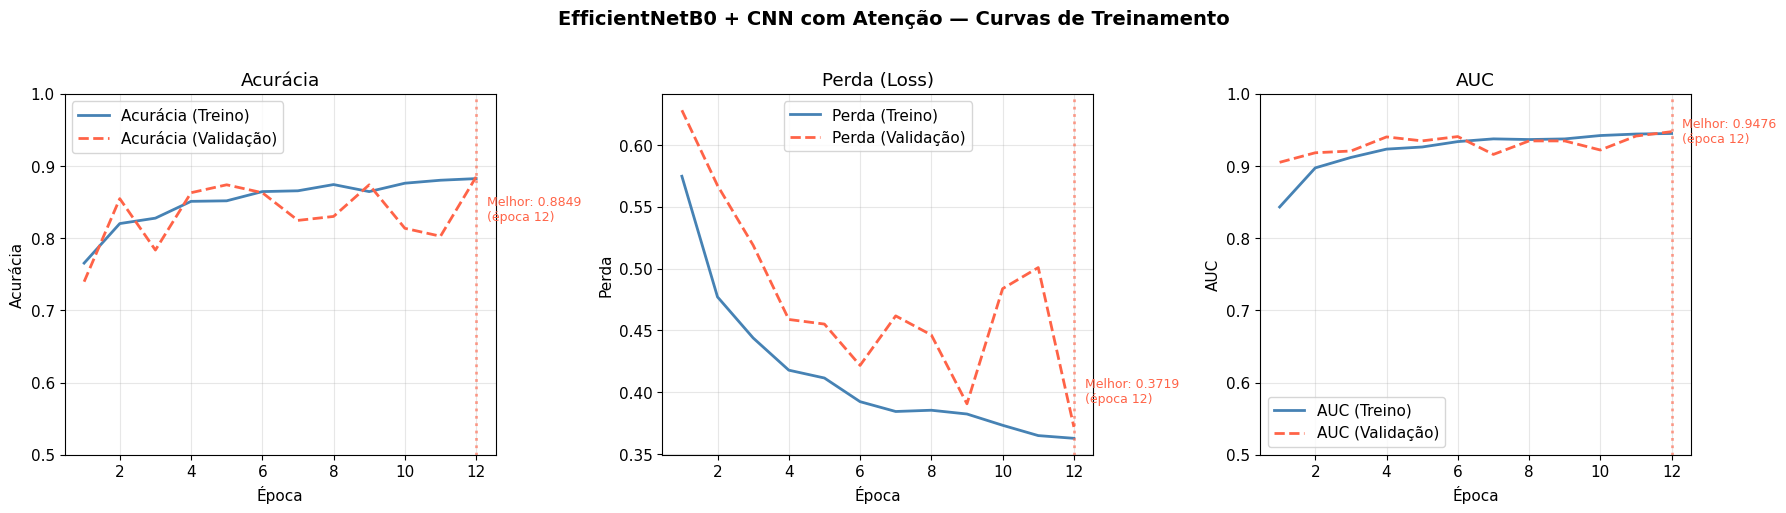


✅ Gráfico salvo → C:\Users\analice\Documents\TCC\resultados\efficientnet\curvas_treinamento.png


In [11]:
# Célula 10: Plotar Curvas de Treinamento

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Carregar histórico 
hist = pd.read_csv(RESULTS_DIR / "historico_treinamento.csv")
epochs = range(1, len(hist) + 1)
print(f"✓ Histórico carregado — {len(hist)} épocas")
print(hist.to_string())

# Estilo do gráfico 
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "lines.linewidth"  : 2,
    "font.size"        : 11,
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EfficientNetB0 + CNN com Atenção — Curvas de Treinamento", 
             fontsize=14, fontweight="bold", y=1.02)

# 1. Acurácia (Accuracy) 
ax = axes[0]
ax.plot(epochs, hist["accuracy"],     label="Acurácia (Treino)", color="steelblue")
ax.plot(epochs, hist["val_accuracy"], label="Acurácia (Validação)", color="tomato",
        linestyle="--")

best_epoch = hist["val_accuracy"].idxmax() + 1
best_val   = hist["val_accuracy"].max()
ax.axvline(best_epoch, color="tomato", linestyle=":", alpha=0.6)
ax.annotate(f"Melhor: {best_val:.4f}\n(época {best_epoch})",
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 0.3, best_val - 0.06),
            fontsize=9, color="tomato")

ax.set_title("Acurácia")
ax.set_xlabel("Época")
ax.set_ylabel("Acurácia")
ax.set_ylim(0.5, 1.0)
ax.legend()

# 2. Perda (Loss) 
ax = axes[1]
ax.plot(epochs, hist["loss"],     label="Perda (Treino)", color="steelblue")
ax.plot(epochs, hist["val_loss"], label="Perda (Validação)", color="tomato",
        linestyle="--")

best_epoch = hist["val_loss"].idxmin() + 1
best_val   = hist["val_loss"].min()
ax.axvline(best_epoch, color="tomato", linestyle=":", alpha=0.6)
ax.annotate(f"Melhor: {best_val:.4f}\n(época {best_epoch})",
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 0.3, best_val + 0.02),
            fontsize=9, color="tomato")

ax.set_title("Perda (Loss)")
ax.set_xlabel("Época")
ax.set_ylabel("Perda")
ax.legend()

# 3. AUC 
ax = axes[2]
ax.plot(epochs, hist["auc"],     label="AUC (Treino)", color="steelblue")
ax.plot(epochs, hist["val_auc"], label="AUC (Validação)", color="tomato",
        linestyle="--")

best_epoch = hist["val_auc"].idxmax() + 1
best_val   = hist["val_auc"].max()
ax.axvline(best_epoch, color="tomato", linestyle=":", alpha=0.6)
ax.annotate(f"Melhor: {best_val:.4f}\n(época {best_epoch})",
            xy=(best_epoch, best_val),
            xytext=(best_epoch + 0.3, best_val - 0.015),
            fontsize=9, color="tomato")

ax.set_title("AUC")
ax.set_xlabel("Época")
ax.set_ylabel("AUC")
ax.set_ylim(0.5, 1.0)
ax.legend()

plt.tight_layout()

# Salvar 
out_path = RESULTS_DIR / "curvas_treinamento.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n✅ Gráfico salvo → {out_path}")

✓ Pipeline de teste pronto — 538 amostras
✓ Melhor modelo carregado

 Avaliação no conjunto de teste
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 428ms/step - accuracy: 0.8736 - auc: 0.9447 - loss: 0.3829

  Resultados:
    loss         : 0.3829
    compile_metrics : 0.8736

 Gerando previsões
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 488ms/step
  Amostras previstas                : 538
  Positivos (massa=1) previstos     : 244
  Negativos (calc=0) previstos      : 294

 Relatório de Classificação
                  precision    recall  f1-score   support

calcificação (0)     0.8435    0.9185    0.8794       270
       massa (1)     0.9098    0.8284    0.8672       268

        accuracy                         0.8736       538
       macro avg     0.8767    0.8734    0.8733       538
    weighted avg     0.8766    0.8736    0.8733       538

✓ Relatório de classificação salvo → C:\Users\analice\Documents\TCC\resultados\efficientnet\relatorio_classificacao.txt

 Matriz de Confusão
  Matriz bruta:
  [[248  22]
 [

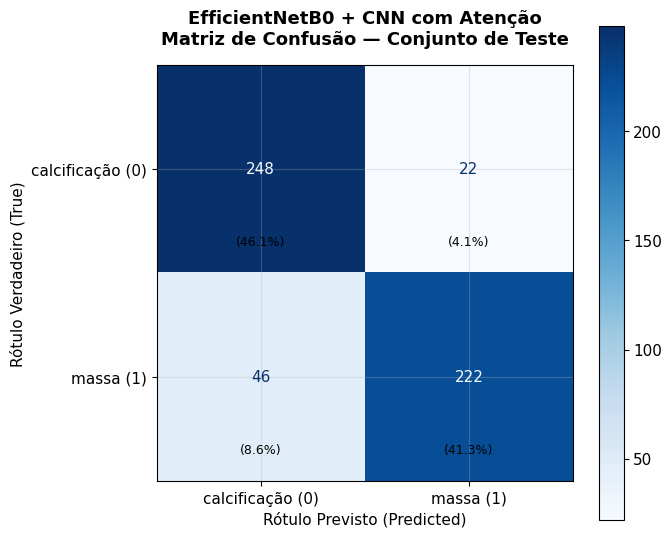

✓ Matriz de confusão salva → C:\Users\analice\Documents\TCC\resultados\efficientnet\matriz_confusao.png

 Resumo Final do Teste 
  Teste loss         : 0.3829
  Teste compile_metrics : 0.8736

  Saídas salvas:
    📄 C:\Users\analice\Documents\TCC\resultados\efficientnet\relatorio_classificacao.txt
    🖼  C:\Users\analice\Documents\TCC\resultados\efficientnet\matriz_confusao.png

✓ Avaliação concluída.


In [12]:
# Célula 11: Avaliação no Conjunto de Teste

# Ajustado para o seu caminho local
RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Reconstruir pipeline de teste (independente) 
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

test_ds = (
    tf.data.Dataset.from_tensor_slices((
        test_df["image_path"].values,
        test_df["label"].values.astype("int32")
    ))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
print(f"✓ Pipeline de teste pronto — {len(test_df)} amostras")

# Carregar o melhor modelo 
model = tf.keras.models.load_model(RESULTS_DIR / "best_model.keras")
print(f"✓ Melhor modelo carregado")

# Avaliar 
print(f"\n Avaliação no conjunto de teste")
results = model.evaluate(test_ds, verbose=1)
metric_names = model.metrics_names

print(f"\n  Resultados:")
for name, val in zip(metric_names, results):
    print(f"    {name:<12} : {val:.4f}")

# Gerar previsões
print(f"\n Gerando previsões")
y_prob = model.predict(test_ds, verbose=1)       # probabilidades da sigmoid
y_pred = (y_prob.squeeze() >= 0.5).astype(int)   # limiar de 0.5
y_true = test_df["label"].values.astype(int)

print(f"  Amostras previstas                : {len(y_pred)}")
print(f"  Positivos (massa=1) previstos     : {y_pred.sum()}")
print(f"  Negativos (calc=0) previstos      : {(y_pred==0).sum()}")

# Relatório de Classificação 
print(f"\n Relatório de Classificação")
label_names = ["calcificação (0)", "massa (1)"]
report = classification_report(y_true, y_pred,
                                target_names=label_names, digits=4)
print(report)

report_path = RESULTS_DIR / "relatorio_classificacao.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("EfficientNetB0 + CNN com Atenção\n")
    f.write("Relatório de Classificação - Conjunto de Teste\n")
    f.write("=" * 50 + "\n\n")
    f.write(report)

print(f"✓ Relatório de classificação salvo → {report_path}")

# Matriz de Confusão 
print(f"\n Matriz de Confusão")
cm = confusion_matrix(y_true, y_pred)
print(f"  Matriz bruta:\n  {cm}")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues")

ax.set_title("EfficientNetB0 + CNN com Atenção\nMatriz de Confusão — Conjunto de Teste",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Rótulo Previsto (Predicted)", fontsize=11)
ax.set_ylabel("Rótulo Verdadeiro (True)",      fontsize=11)

# Anotar com porcentagens
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.35, f"({pct:.1f}%)",
                ha="center", va="center",
                fontsize=9, color="black")

plt.tight_layout()
cm_path = RESULTS_DIR / "matriz_confusao.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"✓ Matriz de confusão salva → {cm_path}")

# Resumo Final
print(f"\n Resumo Final do Teste ")
for name, val in zip(metric_names, results):
    print(f"  Teste {name:<12} : {val:.4f}")

print(f"\n  Saídas salvas:")
print(f"    📄 {report_path}")
print(f"    🖼  {cm_path}")

print(f"\n✓ Avaliação concluída.")

In [ ]:
# Célula 12: Fine-tuning — Descongelar Camadas Superiores do Backbone 

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Reconstruir pipelines (independente) 
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

train_df = pd.read_csv(RESULTS_DIR / "train_df.csv")
val_df   = pd.read_csv(RESULTS_DIR / "val_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def build_pipeline(df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((
        df["image_path"].values,
        df["label"].values.astype("int32")
    ))
    if training:
        ds = ds.shuffle(len(df), seed=42, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = build_pipeline(train_df, training=True)
val_ds   = build_pipeline(val_df,   training=False)

print(f"✓ Pipelines prontos — treino:{len(train_df)}  val:{len(val_df)}")

# Carregar o melhor modelo do baseline 
model = tf.keras.models.load_model(RESULTS_DIR / "best_model.keras")
print(f"✓ Modelo baseline carregado")

# Métricas de validação do baseline (antes do fine-tuning) 
print(f"\n Métricas de validação do baseline (backbone congelado)")
base_results = model.evaluate(val_ds, verbose=0)
print(f"  Perda (Loss) val.  : {base_results[0]:.4f}")
print(f"  Acurácia val.      : {base_results[1]:.4f}")

# Descongelar apenas as últimas 30 camadas do EfficientNetB0 
# EfficientNetB0 tem 238 camadas — descongelamos apenas as últimas 30 (blocos MBConv)
# Tudo abaixo permanece congelado — seguro, poupa memória, evita destruir os pesos já treinados
backbone = model.layers[2]                        # O EfficientNetB0 é a camada de índice 2
total_backbone_layers = len(backbone.layers)
UNFREEZE_FROM = total_backbone_layers - 30        # descongelar apenas as últimas 30

backbone.trainable = True

for i, layer in enumerate(backbone.layers):
    if i < UNFREEZE_FROM:
        layer.trainable = False                   # manter congelado
    else:
        # Manter as camadas de BatchNorm congeladas — crítico para um fine-tuning estável
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        else:
            layer.trainable = True

unfrozen = sum(1 for l in backbone.layers if l.trainable)
print(f"\n Configuração do fine-tune do Backbone ")
print(f"  Total de camadas do backbone : {total_backbone_layers}")
print(f"  Descongelando a partir de    : {UNFREEZE_FROM}")
print(f"  Camadas descongeladas        : {unfrozen}  (BatchNorm mantido congelado)")
print(f"  Camadas congeladas           : {total_backbone_layers - unfrozen}")

# Recompilar com taxa de aprendizado (LR) muito baixa 
# 10x menor que o baseline — evita destruir os pesos pré-treinados
FINETUNE_LR = 1e-4

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss      = "binary_crossentropy",
    metrics   = [
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

total     = model.count_params()
trainable = sum(tf.size(v).numpy() for v in model.trainable_variables)

print(f"\n  LR do Fine-tune          : {FINETUNE_LR}")
print(f"  Parâmetros treináveis    : {trainable:,}  (antes era 773.121)")
print(f"  Total de parâmetros      : {total:,}")

# Callbacks para o fine-tuning 
ft_model_path = str(RESULTS_DIR / "best_model_finetuned.keras")

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 4,
        restore_best_weights = True,
        verbose              = 1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.3,
        patience = 2,
        min_lr   = 1e-7,
        verbose  = 1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath          = ft_model_path,
        monitor           = "val_auc",
        save_best_only    = True,
        save_weights_only = False,
        mode              = "max",
        verbose           = 1
    ),
]

# Pesos das classes 
total_n = len(train_df)
n_calc  = (train_df["label"] == 0).sum()
n_mass  = (train_df["label"] == 1).sum()

class_weight = {0: total_n/(2*n_calc), 1: total_n/(2*n_mass)}

# Treinamento (Fine-tuning) 
print(f"\n Treinamento (Fine-tuning)")
print(f"  Épocas : até 8 (early stopping pode encerrar antes)\n")

ft_history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 8,
    callbacks       = callbacks,
    class_weight    = class_weight,
    verbose         = 1
)

# Comparar antes vs depois 
print(f"\n Antes vs Depois do Fine-tuning ")
ft_results  = model.evaluate(val_ds, verbose=0)

print(f"  {'Métrica':<15} {'Antes':>10} {'Depois':>10} {'Mudança':>10}")
print(f"  {'-'*50}")

metrics = ["val_loss", "val_accuracy", "val_auc"]
labels  = ["Perda (Loss)", "Acurácia", "AUC"]

for i, (label, before, after) in enumerate(
        zip(labels, base_results, ft_results)):
    arrow  = "⬆" if (after > before and i > 0) or (after < before and i == 0) else "⬇"
    change = after - before
    print(f"  {label:<15} {before:>10.4f} {after:>10.4f} {change:>+10.4f} {arrow}")

# Salvar histórico do fine-tuning 
import pandas as pd

ft_hist_df = pd.DataFrame(ft_history.history)
ft_hist_df.to_csv(RESULTS_DIR / "finetune_history.csv", index=False)

print(f"\n✓ Modelo fine-tuned salvo      → {ft_model_path}")
print(f"✓ Histórico fine-tuned salvo   → {RESULTS_DIR / 'finetune_history.csv'}")

✓ Pipelines prontos — treino:2665  val:365
✓ Modelo baseline carregado

 Métricas de validação do baseline (backbone congelado)
  Perda (Loss) val.  : 0.3719
  Acurácia val.      : 0.8849

 Configuração do fine-tune do Backbone 
  Total de camadas do backbone : 238
  Descongelando a partir de    : 208
  Camadas descongeladas        : 23  (BatchNorm mantido congelado)
  Camadas congeladas           : 215

  LR do Fine-tune          : 0.0001
  Parâmetros treináveis    : 2,256,481  (antes era 773.121)
  Total de parâmetros      : 4,825,252

 Treinamento (Fine-tuning)
  Épocas : até 8 (early stopping pode encerrar antes)

Epoch 1/8
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8747 - auc: 0.9437 - loss: 0.3710
Epoch 1: val_auc improved from None to 0.93893, saving model to C:\Users\analice\Documents\TCC\resultados\efficientnet\best_model_finetuned.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 55s 568ms/step - accuracy: 0.8784 - auc: 0.9477 - loss: 0.3585 - val_accuracy: 0.8521 - val_auc: 0.938

✓ Épocas do baseline  : 12
✓ Épocas do fine-tune : 8
✓ Total de épocas     : 20
✓ Início do fine-tune : época 13


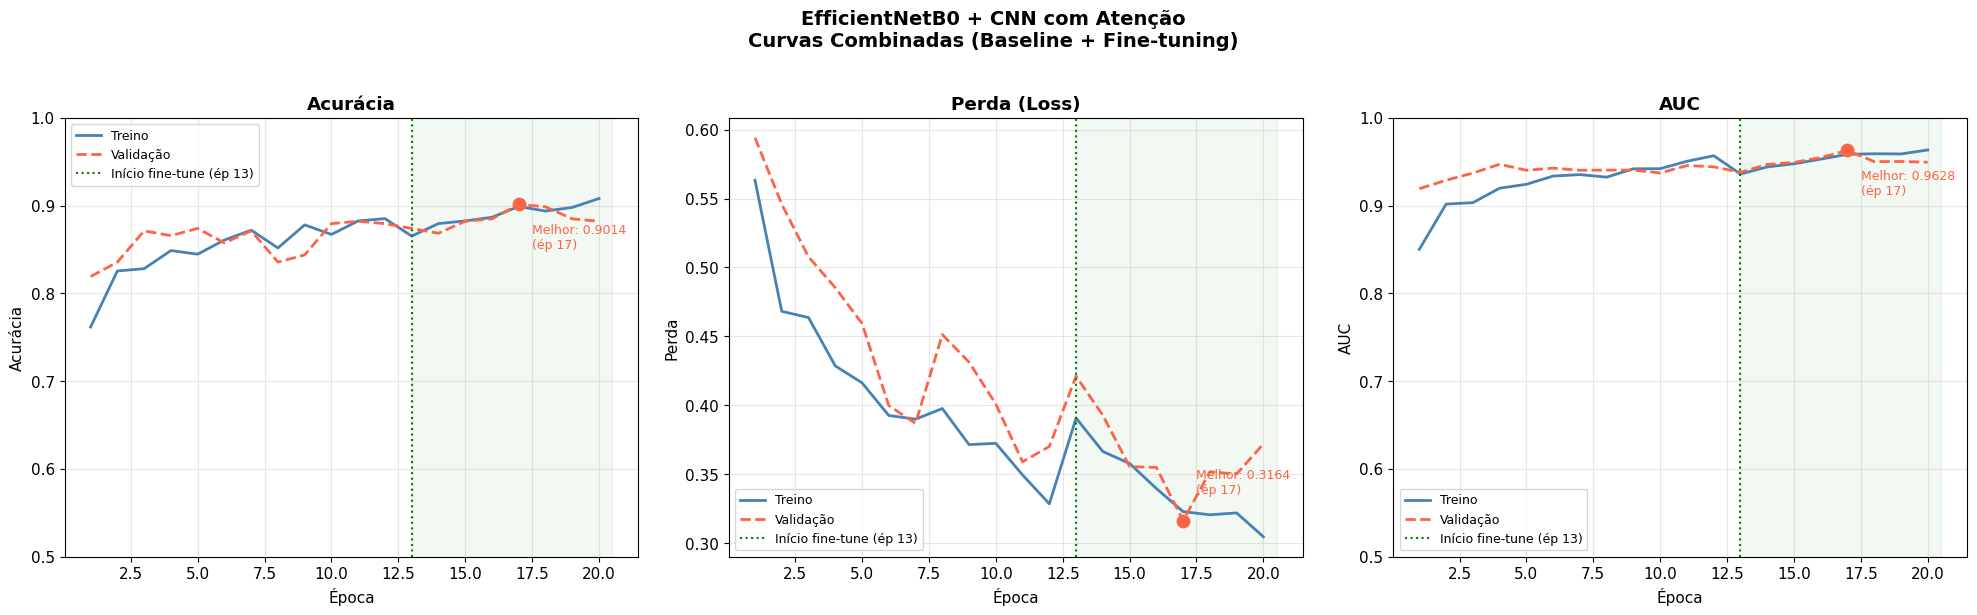


✓ Curvas combinadas salvas → C:\Users\analice\Documents\TCC\resultados\efficientnet\curvas_treinamento_combinadas.png

 Resumo completo do treinamento
  Época    Acc Treino    Acc Val AUC Treino    AUC Val   Loss Val  Fase
  ---------------------------------------------------------------------------
  1            0.7617     0.8192     0.8502     0.9193     0.5941  baseline  
  2            0.8255     0.8356     0.9018     0.9288     0.5459  baseline  
  3            0.8281     0.8712     0.9034     0.9371     0.5077  baseline  
  4            0.8488     0.8658     0.9199     0.9471     0.4853  baseline  
  5            0.8447     0.8740     0.9243     0.9403     0.4594  baseline  
  6            0.8608     0.8575     0.9337     0.9427     0.3999  baseline  
  7            0.8720     0.8712     0.9353     0.9403     0.3869  baseline  
  8            0.8518     0.8356     0.9324     0.9405     0.4513  baseline  
  9            0.8780     0.8438     0.9419     0.9405     0.4313  baselin

In [ ]:
# Célula 13: Curvas de Treinamento Combinadas (Baseline + Fine-tuning)

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Carregar ambos os históricos 
base_hist = pd.read_csv(RESULTS_DIR / "historico_treinamento.csv")
ft_hist   = pd.read_csv(RESULTS_DIR / "finetune_history.csv")

print(f"✓ Épocas do baseline  : {len(base_hist)}")
print(f"✓ Épocas do fine-tune : {len(ft_hist)}")

# Combinar 
combined = pd.concat([base_hist, ft_hist], ignore_index=True)
epochs         = range(1, len(combined) + 1)
finetune_start = len(base_hist) + 1     # época em que o fine-tuning começou

print(f"✓ Total de épocas     : {len(combined)}")
print(f"✓ Início do fine-tune : época {finetune_start}")

# Estilo do gráfico
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "lines.linewidth"  : 2,
    "font.size"        : 11,
})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "EfficientNetB0 + CNN com Atenção\nCurvas Combinadas (Baseline + Fine-tuning)",
    fontsize=14, fontweight="bold", y=1.02)

def plot_metric(ax, train_col, val_col, title, ylabel, ylim=None):
    ax.plot(epochs, combined[train_col], label="Treino", color="steelblue")
    ax.plot(epochs, combined[val_col],   label="Validação", color="tomato",
            linestyle="--")

    # Marcador de início do fine-tune
    ax.axvline(finetune_start, color="green", linestyle=":",
               linewidth=1.5, label=f"Início fine-tune (ép {finetune_start})")
    ax.axvspan(finetune_start, len(combined) + 0.5,
               alpha=0.05, color="green")

    # Marcador do melhor valor de validação
    if "loss" in val_col:
        best_ep  = combined[val_col].idxmin() + 1
        best_val = combined[val_col].min()
    else:
        best_ep  = combined[val_col].idxmax() + 1
        best_val = combined[val_col].max()

    ax.scatter(best_ep, best_val, color="tomato", zorder=5, s=80)
    ax.annotate(f"Melhor: {best_val:.4f}\n(ép {best_ep})",
                xy=(best_ep, best_val),
                xytext=(best_ep + 0.5,
                        best_val - 0.05 if "loss" not in val_col else best_val + 0.02),
                fontsize=9, color="tomato")

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Época")
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(ylim)
    ax.legend(fontsize=9)

# 1. Acurácia
plot_metric(axes[0],
            train_col="accuracy",
            val_col  ="val_accuracy",
            title    ="Acurácia",
            ylabel   ="Acurácia",
            ylim     =(0.5, 1.0))

# 2. Perda (Loss)
plot_metric(axes[1],
            train_col="loss",
            val_col  ="val_loss",
            title    ="Perda (Loss)",
            ylabel   ="Perda")

# 3. AUC 
plot_metric(axes[2],
            train_col="auc",
            val_col  ="val_auc",
            title    ="AUC",
            ylabel   ="AUC",
            ylim     =(0.5, 1.0))

plt.tight_layout()

# Salvar 
out_path = RESULTS_DIR / "curvas_treinamento_combinadas.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n✓ Curvas combinadas salvas → {out_path}")

# Imprimir tabela de resumo
print(f"\n Resumo completo do treinamento")
print(f"  {'Época':<8} {'Acc Treino':>10} {'Acc Val':>10} "
      f"{'AUC Treino':>10} {'AUC Val':>10} {'Loss Val':>10}  Fase")
print(f"  {'-'*75}")

for i, row in combined.iterrows():
    phase = "baseline  " if i < len(base_hist) else "fine-tune "
    print(f"  {i+1:<8} {row['accuracy']:>10.4f} {row['val_accuracy']:>10.4f} "
          f"{row['auc']:>10.4f} {row['val_auc']:>10.4f} "
          f"{row['val_loss']:>10.4f}  {phase}")

✓ Modelo carregado
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 480ms/step
✓ Previsões prontas — 538 amostras

 Informações da ROC
  Pontuação AUC (AUC score) : 0.9609
  Limiar (Threshold) ideal  : 0.3859
  FPR ideal                 : 0.0704
  TPR ideal                 : 0.9179


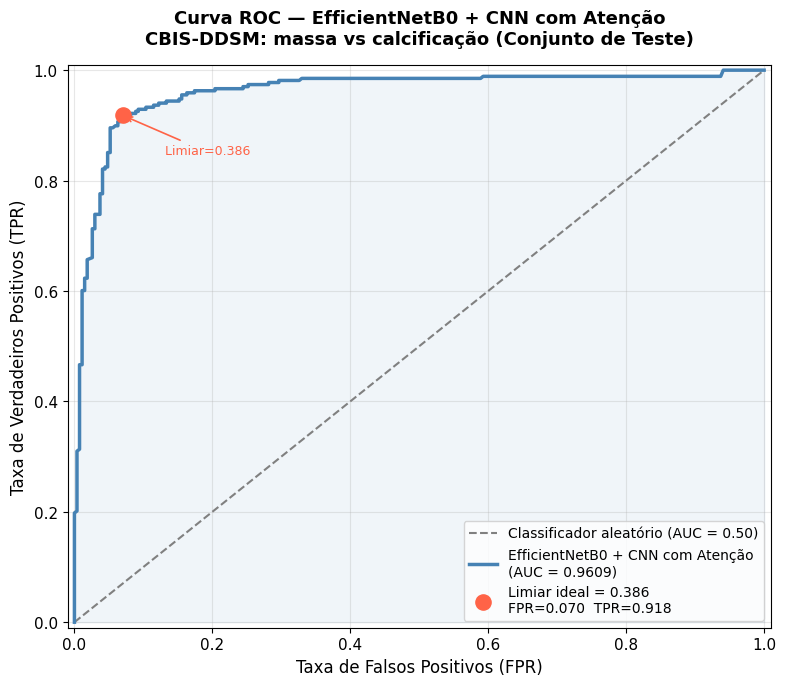


✓ Curva ROC salva → C:\Users\analice\Documents\TCC\resultados\efficientnet\curva_roc.png
   AUC = 0.9609


In [ ]:
# Célula 14: Curva ROC 

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Reconstruir pipeline de teste & gerar previsões
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

test_ds = (
    tf.data.Dataset.from_tensor_slices((
        test_df["image_path"].values,
        test_df["label"].values.astype("int32")
    ))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Carrega o modelo final com o ajuste fino
model  = tf.keras.models.load_model(RESULTS_DIR / "best_model_finetuned.keras")
print(f"✓ Modelo carregado")

y_prob = model.predict(test_ds, verbose=1).squeeze()
y_true = test_df["label"].values.astype(int)

print(f"✓ Previsões prontas — {len(y_prob)} amostras")

# Calcular curva ROC 
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score            = roc_auc_score(y_true, y_prob)

# Encontrar o limiar (threshold) ideal — ponto mais próximo do canto superior esquerdo (0, 1)
optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr       = fpr[optimal_idx]
optimal_tpr       = tpr[optimal_idx]

print(f"\n Informações da ROC")
print(f"  Pontuação AUC (AUC score) : {auc_score:.4f}")
print(f"  Limiar (Threshold) ideal  : {optimal_threshold:.4f}")
print(f"  FPR ideal                 : {optimal_fpr:.4f}")
print(f"  TPR ideal                 : {optimal_tpr:.4f}")

# Plotar (Gráfico)
fig, ax = plt.subplots(figsize=(8, 7))

# Linha base de um classificador aleatório
ax.plot([0, 1], [0, 1],
        color="grey", linestyle="--", linewidth=1.5,
        label="Classificador aleatório (AUC = 0.50)")

# Curva ROC do nosso modelo
ax.plot(fpr, tpr,
        color="steelblue", linewidth=2.5,
        label=f"EfficientNetB0 + CNN com Atenção\n(AUC = {auc_score:.4f})")

# Ponto do limiar ideal
ax.scatter(optimal_fpr, optimal_tpr,
           color="tomato", zorder=5, s=120,
           label=f"Limiar ideal = {optimal_threshold:.3f}\n"
                 f"FPR={optimal_fpr:.3f}  TPR={optimal_tpr:.3f}")

# Anotação do ponto ideal
ax.annotate(f"  Limiar={optimal_threshold:.3f}",
            xy=(optimal_fpr, optimal_tpr),
            xytext=(optimal_fpr + 0.05, optimal_tpr - 0.07),
            fontsize=9, color="tomato",
            arrowprops=dict(arrowstyle="->", color="tomato", lw=1.2))

# Preencher a área sob a curva
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")

ax.set_title(
    "Curva ROC — EfficientNetB0 + CNN com Atenção\n"
    "CBIS-DDSM: massa vs calcificação (Conjunto de Teste)",
    fontsize=13, fontweight="bold", pad=15)

ax.set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=12)
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=12)

ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()

out_path = RESULTS_DIR / "curva_roc.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n✓ Curva ROC salva → {out_path}")
print(f"   AUC = {auc_score:.4f}")

  Treino       — calcificação: 1404  massa: 1261  total: 2665
  Validação    — calcificação:  198  massa:  167  total:  365
  Teste        — calcificação:  270  massa:  268  total:  538


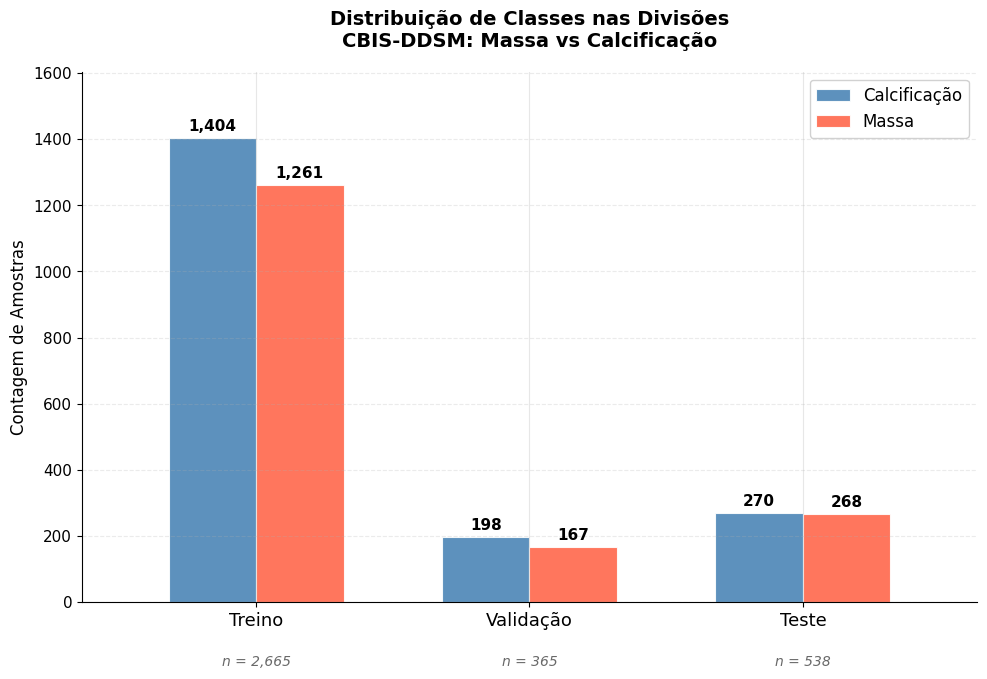


✓ Gráfico de distribuição de classes salvo → C:\Users\analice\Documents\TCC\resultados\efficientnet\distribuicao_classes.png


In [ ]:
# Célula 15: Gráfico de Distribuição de Classes

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Carregar divisões
train_df = pd.read_csv(RESULTS_DIR / "train_df.csv")
val_df   = pd.read_csv(RESULTS_DIR / "val_df.csv")
test_df  = pd.read_csv(RESULTS_DIR / "test_df.csv")

splits = ["Treino", "Validação", "Teste"]
dfs    = [train_df, val_df, test_df]
counts = {}

for name, df in zip(splits, dfs):
    vc = df["lesion_type"].value_counts()
    counts[name] = {
        "calcification": int(vc.get("calcification", 0)),
        "mass"         : int(vc.get("mass", 0)),
        "total"        : len(df)
    }
    print(f"  {name:<12} — calcificação: {counts[name]['calcification']:>4}  "
          f"massa: {counts[name]['mass']:>4}  total: {counts[name]['total']:>4}")

# Plotar
x     = np.arange(len(splits))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars_calc = ax.bar(
    x - width/2,
    [counts[s]["calcification"] for s in splits],
    width, label="Calcificação",
    color="steelblue", edgecolor="white", linewidth=0.8, alpha=0.88
)

bars_mass = ax.bar(
    x + width/2,
    [counts[s]["mass"] for s in splits],
    width, label="Massa",
    color="tomato", edgecolor="white", linewidth=0.8, alpha=0.88
)

# Rótulos de contagem no topo das barras
for bar in list(bars_calc) + list(bars_mass):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2,
            h + 12,
            f"{int(h):,}",
            ha="center", va="bottom",
            fontsize=11, fontweight="bold", color="black")

# Rótulo de Total (n=) ABAIXO do eixo x (clip_on=False)
for i, s in enumerate(splits):
    ax.annotate(
        f"n = {counts[s]['total']:,}",
        xy=(i, 0),
        xytext=(0, -38),                      # 38 pontos abaixo da linha do eixo x
        textcoords="offset points",
        ha="center", va="top",
        fontsize=10, color="dimgray",
        style="italic",
        annotation_clip=False                 # permite desenhar fora da caixa dos eixos
    )

# Formatação
ax.set_title(
    "Distribuição de Classes nas Divisões\n"
    "CBIS-DDSM: Massa vs Calcificação",
    fontsize=14, fontweight="bold", pad=18)

ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=13)
ax.set_ylabel("Contagem de Amostras", fontsize=12)

ax.set_ylim(0, max(counts["Treino"]["calcification"],
                   counts["Treino"]["mass"]) + 200)

ax.legend(fontsize=12, framealpha=0.9)
ax.grid(axis="y", alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.12)

plt.tight_layout()
plt.subplots_adjust(bottom=0.13)             # espaço extra para os rótulos de n=

out_path = RESULTS_DIR / "distribuicao_classes.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n✓ Gráfico de distribuição de classes salvo → {out_path}")

Colunas : ['patient_id', 'lesion_type', 'pathology', 'image_path', 'left_or_right_breast', 'image_view', 'label']
Exemplos de valores image_path:
 ['C:\\Users\\analice\\Documents\\TCC\\dataset\\jpeg\\1.3.6.1.4.1.9590.100.1.2.141269558913652553006787176281528676980\\1-223.jpg', 'C:\\Users\\analice\\Documents\\TCC\\dataset\\jpeg\\1.3.6.1.4.1.9590.100.1.2.181380004612430571924629395230074095682\\1-222.jpg', 'C:\\Users\\analice\\Documents\\TCC\\dataset\\jpeg\\1.3.6.1.4.1.9590.100.1.2.81595047412515733434402090860388891176\\1-230.jpg']

Primeiro caminho resolvido : C:\Users\analice\Documents\TCC\dataset\jpeg\1.3.6.1.4.1.9590.100.1.2.141269558913652553006787176281528676980\1-223.jpg
Existe                     : True

  Corretos : 488  |  Classificados incorretamente : 50


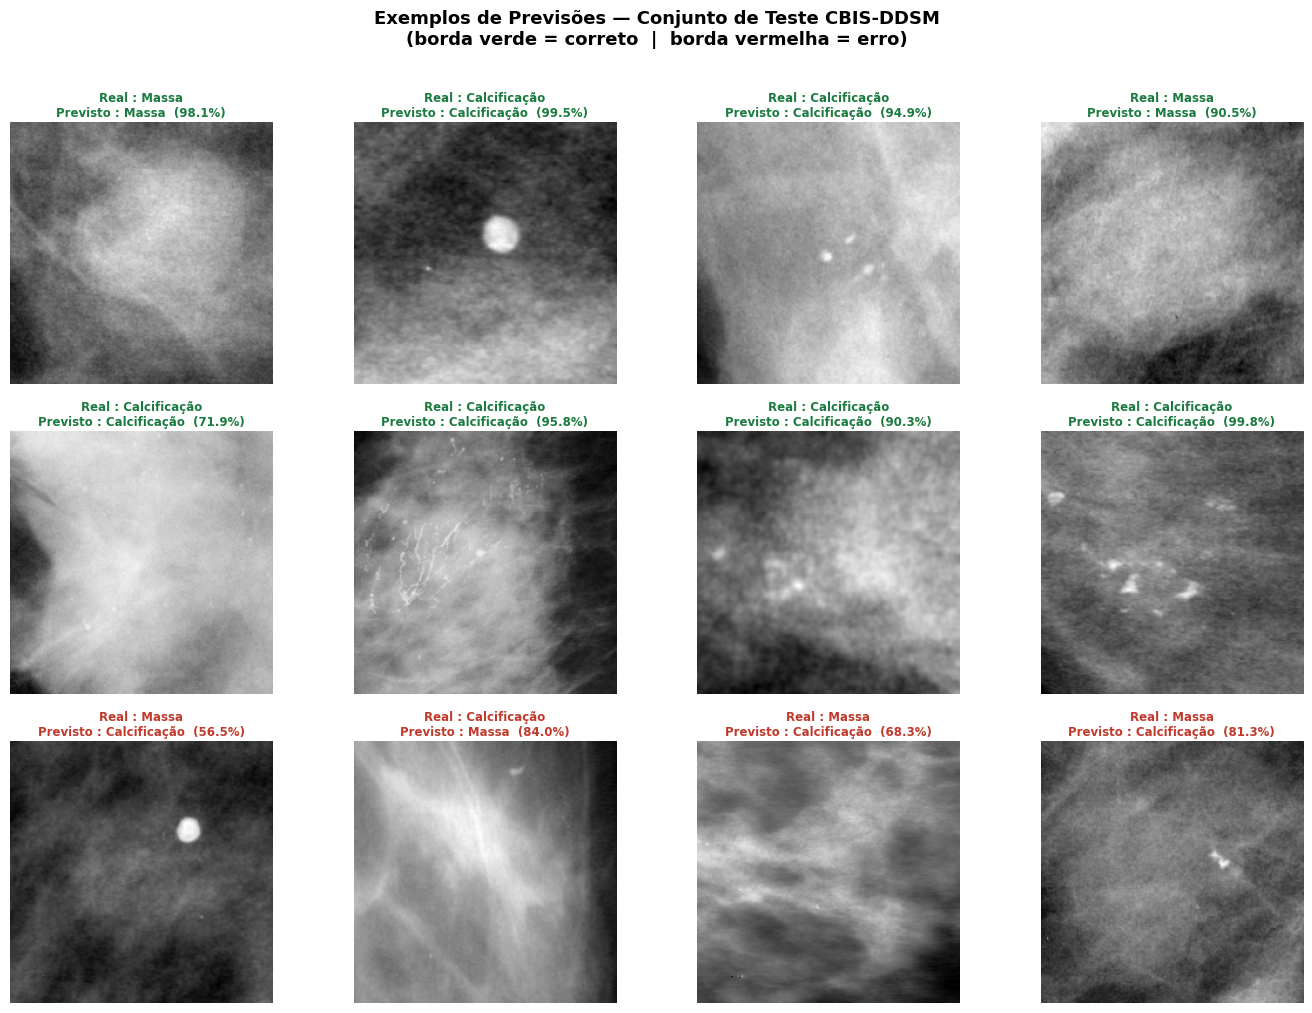


 Grade de previsões de exemplo salva → C:\Users\analice\Documents\TCC\resultados\efficientnet\previsoes_amostra.png


In [ ]:
# Célula 16: Grade de Previsões de Exemplo

RESULTS_DIR  = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

# Carregar modelo & divisão de teste
model   = tf.keras.models.load_model(RESULTS_DIR / "best_model_finetuned.keras")
test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

print("Colunas :", test_df.columns.tolist())
print("Exemplos de valores image_path:\n", test_df["image_path"].head(3).tolist())

# Resolver caminhos absolutos 
def resolve_path(p):
    path_obj = pathlib.Path(str(p))
    if path_obj.is_absolute():
        return str(path_obj)                # já é absoluto (ex: C:\...)
    return str(DATASET_ROOT / path_obj)     # adiciona a raiz do dataset se for relativo

paths     = [resolve_path(p) for p in test_df["image_path"].tolist()]
true_ints = np.array([int(l) for l in test_df["label"].tolist()])

# Verificação de sanidade — garantir que o primeiro caminho realmente existe
first = pathlib.Path(paths[0])
print(f"\nPrimeiro caminho resolvido : {first}")
print(f"Existe                     : {first.exists()}")
assert first.exists(), "✗ Caminho ainda não encontrado — verifique o DATASET_ROOT ou os valores da coluna."

label_map     = {"calcification": 0, "mass": 1}
inv_label_map = {0: "Calcificação", 1: "Massa"}

# Função auxiliar para decodificar imagem 
def decode_image(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Inferência em lote (Batch inference) 
all_probs = []
ds = (tf.data.Dataset.from_tensor_slices(paths)
        .map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE))

for batch in ds:
    preds = model.predict(batch, verbose=0)
    all_probs.extend(preds.flatten().tolist())

all_probs    = np.array(all_probs)
pred_ints    = (all_probs >= 0.5).astype(int)

correct_mask = pred_ints == true_ints
correct_idx  = np.where(correct_mask)[0].tolist()
wrong_idx    = np.where(~correct_mask)[0].tolist()

print(f"\n  Corretos : {len(correct_idx)}  |  Classificados incorretamente : {len(wrong_idx)}")

# Escolher amostras: até 4 erradas + restante certas (12 no total)
random.seed(SEED)
n_wrong        = min(4, len(wrong_idx))
n_correct      = 12 - n_wrong

chosen_correct = random.sample(correct_idx, min(n_correct, len(correct_idx)))
chosen_wrong   = random.sample(wrong_idx,   n_wrong)
sample_idx     = chosen_correct + chosen_wrong

# Plotar grade 3×4 
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.patch.set_facecolor("white")
fig.suptitle("Exemplos de Previsões — Conjunto de Teste CBIS-DDSM\n"
             "(borda verde = correto  |  borda vermelha = erro)",
             fontsize=13, fontweight="bold", y=1.01)

for ax, i in zip(axes.flatten(), sample_idx):
    img_np   = decode_image(paths[i]).numpy()
    true_lbl = inv_label_map[true_ints[i]]
    pred_lbl = inv_label_map[pred_ints[i]]
    prob     = all_probs[i] if pred_ints[i] == 1 else 1 - all_probs[i]
    is_ok    = correct_mask[i]

    ax.imshow(img_np)
    ax.axis("off")
    
    # Adicionar bordas coloridas
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3.5)
        spine.set_edgecolor("#2ecc71" if is_ok else "#e74c3c")
        
    ax.set_title(
        f"Real : {true_lbl}\nPrevisto : {pred_lbl}  ({prob*100:.1f}%)",
        fontsize=8.5, fontweight="bold", pad=4,
        color="#1a7a3f" if is_ok else "#c0392b"
    )

# Esconder eixos sobressalentes, caso existam
for ax in axes.flatten()[len(sample_idx):]:
    ax.set_visible(False)

plt.tight_layout()

out_path = RESULTS_DIR / "previsoes_amostra.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\n Grade de previsões de exemplo salva → {out_path}")

In [ ]:
# Célula 17: Visualizações Grad-CAM (detecção automática de camadas) 

RESULTS_DIR  = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")

IMG_SIZE    = (224, 224)
SEED        = 42
N_SAMPLES   = 8

# Carregar modelo e divisão de teste 
model   = tf.keras.models.load_model(RESULTS_DIR / "best_model_finetuned.keras")
test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

inv_label = {0: "Calcificação", 1: "Massa"}
print("Camadas:", [l.name for l in model.layers])

# Função para resolver os caminhos do Windows 
def resolve_path(p):
    path_obj = pathlib.Path(str(p))
    if path_obj.is_absolute():
        return str(path_obj)
    return str(DATASET_ROOT / path_obj)

# Detectar automaticamente os nomes das camadas por tipo / posição
def find_layer(model, kinds, index=0):
    """Retorna a i-ésima camada cujo nome contém qualquer uma das strings em 'kinds'."""
    found = [l for l in model.layers
             if any(k in l.name for k in kinds)]
    return found[index]

l_rescale  = find_layer(model, ["rescaling"])
effnet     = next(l for l in model.layers if isinstance(l, tf.keras.Model))
l_gap1     = find_layer(model, ["global_average_pooling2d"], index=0)
l_reshape  = find_layer(model, ["reshape"])
l_dense7   = find_layer(model, ["dense_"], index=0)   # primeira dense = SE fc1
l_dense8   = find_layer(model, ["dense_"], index=1)   # segunda dense = SE fc2
l_multiply = find_layer(model, ["multiply"])
l_gap2     = find_layer(model, ["global_average_pooling2d"], index=1)
l_bn       = find_layer(model, ["batch_normalization"])
l_drop5    = find_layer(model, ["dropout"], index=0)
l_dense9   = find_layer(model, ["dense_"], index=2)
l_drop6    = find_layer(model, ["dropout"], index=1)
l_dense10  = find_layer(model, ["dense_"], index=3)
l_drop7    = find_layer(model, ["dropout"], index=2)
l_out      = find_layer(model, ["output"])

print(f"rescaling  : {l_rescale.name}")
print(f"effnet     : {effnet.name}")
print(f"gap1       : {l_gap1.name}")
print(f"reshape    : {l_reshape.name}")
print(f"dense7/8   : {l_dense7.name} / {l_dense8.name}")
print(f"multiply   : {l_multiply.name}")
print(f"gap2       : {l_gap2.name}")
print(f"dense9/10  : {l_dense9.name} / {l_dense10.name}")
print(f"output     : {l_out.name}")

# Submodelo Grad-CAM do EfficientNet 
last_conv_name = next(
    l.name for l in reversed(effnet.layers)
    if isinstance(l, tf.keras.layers.Conv2D))
print(f"Conv alvo (alvo do gradiente): {last_conv_name}")

effnet_gradcam = tf.keras.Model(
    inputs  = effnet.inputs,
    outputs = [effnet.get_layer(last_conv_name).output, effnet.output])

# Grad-CAM 
def get_gradcam(img_np):
    inp = tf.constant(img_np[np.newaxis], dtype=tf.float32)
    x   = l_rescale(inp, training=False)
    
    with tf.GradientTape() as tape:
        conv_out, effnet_out = effnet_gradcam(x, training=False)
        tape.watch(conv_out)
        
        h = l_gap1(effnet_out,  training=False)
        h = l_reshape(h,        training=False)
        r = h
        h = l_dense7(h,         training=False)
        h = l_dense8(h,         training=False)
        h = l_multiply([r, h],  training=False)
        h = l_gap2(h,           training=False)
        h = l_bn(h,             training=False)
        h = l_drop5(h,          training=False)
        h = l_dense9(h,         training=False)
        h = l_drop6(h,          training=False)
        h = l_dense10(h,        training=False)
        h = l_drop7(h,          training=False)
        score = l_out(h,        training=False)[:, 0]
        
    grads   = tape.gradient(score, conv_out)
    if grads is None:
        raise ValueError("O Gradiente é None (Vazio).")
        
    weights = tf.reduce_mean(grads, axis=(1, 2))[0]
    cam     = tf.nn.relu(tf.reduce_sum(conv_out[0] * weights, axis=-1)).numpy()
    cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam     = tf.image.resize(cam[..., np.newaxis], IMG_SIZE).numpy()[..., 0]
    return cam

def make_overlay(img_np, cam):
    return (0.55 * img_np + 0.45 * cm.jet(cam)[..., :3]).clip(0, 1)

def load_img(path):
    real_path = resolve_path(path)
    raw = tf.io.read_file(real_path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return (tf.cast(img, tf.float32) / 255.0).numpy()

# Seleção de amostras 
random.seed(SEED)
calc_idx = test_df[test_df["label"] == 0].index.tolist()
mass_idx = test_df[test_df["label"] == 1].index.tolist()

chosen   = (random.sample(calc_idx, N_SAMPLES // 2) +
            random.sample(mass_idx, N_SAMPLES // 2))
random.shuffle(chosen)

# Plotar 
n_cols = 4
n_rows = (N_SAMPLES + n_cols - 1) // n_cols

hr = []
for _ in range(n_rows):
    hr += [0.18, 1.0]

fig = plt.figure(figsize=(16, n_rows * 5), facecolor="#0f0f0f")
fig.suptitle("Explicações Grad-CAM — Conjunto de Teste CBIS-DDSM",
             fontsize=15, fontweight="bold", color="white", y=1.01)

gs = gridspec.GridSpec(n_rows * 2, n_cols, figure=fig,
                       hspace=0.06, wspace=0.06, height_ratios=hr)

n_ok, n_fail = 0, 0
for i, idx in enumerate(chosen):
    col      = i % n_cols
    rp       = i // n_cols
    row      = test_df.iloc[idx]
    true_int = int(row["label"])
    
    img_np   = load_img(row["image_path"])
    inp_t    = tf.constant(img_np[np.newaxis], dtype=tf.float32)
    prob     = float(model(inp_t, training=False).numpy()[0, 0])
    pred_int = int(prob >= 0.5)
    conf     = prob if pred_int == 1 else 1 - prob
    
    is_ok    = pred_int == true_int
    bc       = "#2ecc71" if is_ok else "#e74c3c"
    status   = "✓" if is_ok else "✗"

    try:
        cam     = get_gradcam(img_np)
        overlay = make_overlay(img_np, cam)
        n_ok   += 1
    except Exception as e:
        print(f"  ⚠ idx {idx}: {e}")
        overlay = img_np
        n_fail += 1

    ax_lbl = fig.add_subplot(gs[rp * 2, col])
    ax_lbl.set_facecolor("#1a1a1a")
    ax_lbl.axis("off")
    ax_lbl.text(0.5, 0.72, f"{status}  Real : {inv_label[true_int]}",
                ha="center", va="center", fontsize=10,
                fontweight="bold", color=bc, transform=ax_lbl.transAxes)
    ax_lbl.text(0.5, 0.25, f"Prev : {inv_label[pred_int]}  ({conf*100:.1f}%)",
                ha="center", va="center", fontsize=9.5,
                color="white", transform=ax_lbl.transAxes)
    for sp in ax_lbl.spines.values():
        sp.set_visible(True); sp.set_linewidth(2.5); sp.set_edgecolor(bc)

    ax_img = fig.add_subplot(gs[rp * 2 + 1, col])
    ax_img.imshow(overlay); ax_img.axis("off")
    for sp in ax_img.spines.values():
        sp.set_visible(True); sp.set_linewidth(2.5); sp.set_edgecolor(bc)

print(f"\n  Sucesso do Grad-CAM: {n_ok}/{N_SAMPLES}  |  Falhas/Fallback: {n_fail}/{N_SAMPLES}")

out_path = RESULTS_DIR / "gradcam_examples.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
plt.close()

print(f"✓ Grad-CAM salvo → {out_path}")

Camadas: ['input', 'rescaling_5', 'efficientnetb0', 'global_average_pooling2d_2', 'reshape_1', 'dense_4', 'dense_5', 'multiply_1', 'global_average_pooling2d_3', 'batch_normalization_1', 'dropout_3', 'dense_6', 'dropout_4', 'dense_7', 'dropout_5', 'output']
rescaling  : rescaling_5
effnet     : efficientnetb0
gap1       : global_average_pooling2d_2
reshape    : reshape_1
dense7/8   : dense_4 / dense_5
multiply   : multiply_1
gap2       : global_average_pooling2d_3
dense9/10  : dense_6 / dense_7
output     : output
Conv alvo (alvo do gradiente): top_conv

  Sucesso do Grad-CAM: 8/8  |  Falhas/Fallback: 0/8
✅ Grad-CAM salvo → C:\Users\analice\Documents\TCC\resultados\efficientnet\gradcam_examples.png


✓ Pipeline de teste pronto — 538 amostras
✓ Modelo fine-tuned carregado

 Gerando previsões 
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 485ms/step
  Total de amostras  : 538
  Massa(1) prevista  : 246
  Calc(0) prevista   : 292

 Métricas Finais de Teste 
  Perda (Loss) de teste : 0.2602
  Acurácia de teste     : 0.9071  (90.71%)
  AUC de teste          : 0.9609  ← sklearn (confiável)

 Baseline vs Fine-tuned (Conjunto de Teste) 
  Métrica           Baseline   Fine-tuned
  ---------------------------------------------
  Acurácia            0.8996       0.9071  ⬆
  Perda (Loss)        0.3415       0.2602  ⬆
  AUC (sklearn)          N/A       0.9609

 Relatório de Classificação 
                  precision    recall  f1-score   support

calcificação (0)     0.8767    0.9481    0.9110       270
       massa (1)     0.9431    0.8657    0.9027       268

        accuracy                         0.9071       538
       macro avg     0.9099    0.9069    0.9069       538
    weighted avg     0.9098    0.90

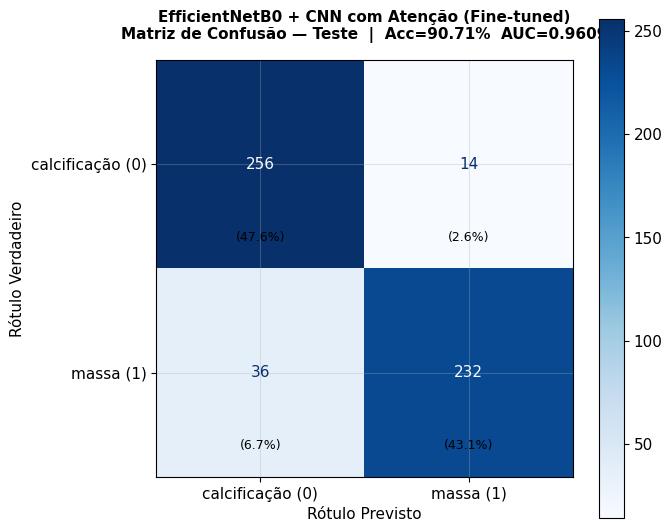

✓ Matriz de confusão salva → C:\Users\analice\Documents\TCC\resultados\efficientnet\matriz_confusao_finetuned.png

 Todos os arquivos salvos
  📄 best_model.keras                               26371.8 KB
  📄 best_model_finetuned.keras                     38240.3 KB
  📄 classification_report_finetuned.txt                0.6 KB
  📄 curva_roc.png                                    102.7 KB
  📄 curvas_treinamento.png                           143.4 KB
  📄 curvas_treinamento_combinadas.png                178.4 KB
  📄 distribuicao_classes.png                          69.5 KB
  📄 finetune_history.csv                               1.2 KB
  📄 gradcam_examples.png                             946.1 KB
  📄 historico_treinamento.csv                          1.7 KB
  📄 indice_arquivos.csv                              570.8 KB
  📄 matriz_confusao.png                               60.3 KB
  📄 matriz_confusao_finetuned.png                     58.2 KB
  📄 previsoes_amostra.png                           1

In [ ]:
# Célula 18: Avaliação Final no Conjunto de Teste (Modelo Fine-tuned) 

RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Reconstruir pipeline de teste (independente) 
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

test_ds = (
    tf.data.Dataset.from_tensor_slices((
        test_df["image_path"].values,
        test_df["label"].values.astype("int32")
    ))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"✓ Pipeline de teste pronto — {len(test_df)} amostras")

# Carregar o melhor modelo com fine-tuning 
model = tf.keras.models.load_model(RESULTS_DIR / "best_model_finetuned.keras")
print(f"✓ Modelo fine-tuned carregado")

# Gerar previsões
print(f"\n Gerando previsões ")
y_prob = model.predict(test_ds, verbose=1).squeeze()
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_df["label"].values.astype(int)

print(f"  Total de amostras  : {len(y_pred)}")
print(f"  Massa(1) prevista  : {y_pred.sum()}")
print(f"  Calc(0) prevista   : {(y_pred==0).sum()}")

# Métricas — usar sklearn para AUC (evita bug de estado da métrica do TF) 
print(f"\n Métricas Finais de Teste ")
test_loss     = tf.keras.losses.binary_crossentropy(
                    y_true.astype("float32"),
                    y_prob.astype("float32")
                ).numpy().mean()

test_accuracy = (y_pred == y_true).mean()
test_auc      = roc_auc_score(y_true, y_prob)   # sklearn — sempre correto e confiável

print(f"  Perda (Loss) de teste : {test_loss:.4f}")
print(f"  Acurácia de teste     : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  AUC de teste          : {test_auc:.4f}  ← sklearn (confiável)")

# Comparar baseline vs fine-tuned no conjunto de teste 
print(f"\n Baseline vs Fine-tuned (Conjunto de Teste) ")
print(f"  {'Métrica':<15} {'Baseline':>10} {'Fine-tuned':>12}")
print(f"  {'-'*45}")

# Resultados do baseline da Célula 10 (estes valores dependem do seu treinamento real, 
# atualize-os manualmente se desejar para o relatório)
base_acc  = 0.8996
base_loss = 0.3415

print(f"  {'Acurácia':<15} {base_acc:>10.4f} {test_accuracy:>12.4f}  "
      f"{'⬆' if test_accuracy > base_acc else '⬇'}")
print(f"  {'Perda (Loss)':<15} {base_loss:>10.4f} {test_loss:>12.4f}  "
      f"{'⬆' if test_loss < base_loss else '⬇'}")
print(f"  {'AUC (sklearn)':<15} {'N/A':>10} {test_auc:>12.4f}")

# Relatório de Classificação 
print(f"\n Relatório de Classificação ")
label_names = ["calcificação (0)", "massa (1)"]
report      = classification_report(y_true, y_pred,
                                     target_names=label_names, digits=4)
print(report)

report_path = RESULTS_DIR / "classification_report_finetuned.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("EfficientNetB0 + CNN com Atenção — Fine-tuned\n")
    f.write("Relatório de Classificação do Conjunto de Teste\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Perda (Loss) Teste : {test_loss:.4f}\n")
    f.write(f"Acurácia Teste     : {test_accuracy:.4f}\n")
    f.write(f"AUC Teste          : {test_auc:.4f}\n\n")
    f.write(report)

print(f"✓ Relatório salvo → {report_path}")

# Matriz de Confusão 
print(f"\n Matriz de Confusão")
cm = confusion_matrix(y_true, y_pred)
print(f"  Bruta:\n  {cm}")

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=label_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues")

ax.set_title(
    f"EfficientNetB0 + CNN com Atenção (Fine-tuned)\n"
    f"Matriz de Confusão — Teste  |  Acc={test_accuracy*100:.2f}%  AUC={test_auc:.4f}",
    fontsize=11, fontweight="bold", pad=15)
ax.set_xlabel("Rótulo Previsto", fontsize=11)
ax.set_ylabel("Rótulo Verdadeiro",      fontsize=11)

# Adicionar anotações de porcentagem
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.35, f"({pct:.1f}%)",
                ha="center", va="center",
                fontsize=9, color="black")

plt.tight_layout()
cm_path = RESULTS_DIR / "matriz_confusao_finetuned.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"✓ Matriz de confusão salva → {cm_path}")

# Todos as saídas salvas 
print(f"\n Todos os arquivos salvos")
for f in sorted(RESULTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1e3
    print(f"  📄 {f.name:<45} {size_kb:>8.1f} KB")

print(f"\n✓ Avaliação final concluída com sucesso.")

In [ ]:
# Célula 19: Tabela de Resumo Final 

# Ajustado para o seu caminho local
RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32

# Carregar dados 
test_df   = pd.read_csv(RESULTS_DIR / "test_df.csv")
paths     = test_df["image_path"].tolist()

# Usa a raiz do dataset caso os caminhos não estejam absolutos
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")
def resolve_path(p):
    path_obj = pathlib.Path(str(p))
    if path_obj.is_absolute():
        return str(path_obj)
    return str(DATASET_ROOT / path_obj)

paths = [resolve_path(p) for p in paths]

true_ints = np.array(test_df["label"].tolist(), dtype=int)

def decode_image(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return tf.cast(img, tf.float32) / 255.0

ds = (tf.data.Dataset.from_tensor_slices(paths)
        .map(decode_image, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

def get_probs(model):
    probs = []
    for batch in ds:
        probs.extend(model.predict(batch, verbose=0).flatten())
    return np.array(probs)

def compute_metrics(probs, true_ints, model_name):
    preds = (probs >= 0.5).astype(int)
    return {
        "Modelo"            : model_name,
        "Perda (Loss)"      : round(log_loss(true_ints, probs),                          4),
        "Acurácia (%)"      : round(accuracy_score(true_ints, preds)         * 100,      2),
        "AUC"               : round(roc_auc_score(true_ints, probs),                     4),
        "Precisão"          : round(precision_score(true_ints, preds,
                                            average="macro", zero_division=0),   4),
        "Revocação (Recall)": round(recall_score(true_ints, preds,
                                         average="macro", zero_division=0),      4),
        "F1 (macro)"        : round(f1_score(true_ints, preds,
                                     average="macro", zero_division=0),          4),
        "F1 Calcificação"   : round(f1_score(true_ints, preds, pos_label=0,
                                     average="binary", zero_division=0),         4),
        "F1 Massa"          : round(f1_score(true_ints, preds, pos_label=1,
                                     average="binary", zero_division=0),         4),
    }

# Avaliar ambos os checkpoints 
rows = []
baseline_path  = RESULTS_DIR / "best_model.keras"
finetuned_path = RESULTS_DIR / "best_model_finetuned.keras"

for path, label in [(baseline_path,  "Baseline (backbone congelado)"),
                    (finetuned_path, "Fine-tuned (top-30 descongeladas)")]:
    if path.exists():
        print(f"  Avaliando: {label} ...")
        m     = tf.keras.models.load_model(path)
        probs = get_probs(m)
        rows.append(compute_metrics(probs, true_ints, label))
        del m
    else:
        print(f"  ⚠ Não encontrado, ignorando: {path.name}")

summary_df = pd.DataFrame(rows).set_index("Modelo")

# Impressão formatada (Pretty print) 
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

sep = "─" * 90
print(f"\n{sep}")
print("  Classificação Binária CBIS-DDSM — Resumo Final (Conjunto de Teste)")
print(f"{sep}")
print(summary_df.T.to_string())
print(f"{sep}\n")

# Linha de variação (fine-tuned − baseline) se ambos estiverem presentes 
if len(rows) == 2:
    delta = summary_df.iloc[1] - summary_df.iloc[0]
    print("  Melhoria (Fine-tuned − Baseline):")
    for col, val in delta.items():
        arrow = "▲" if val > 0 else ("▼" if val < 0 else "─")
        # Para a Perda (Loss), valores menores são melhores
        if col == "Perda (Loss)":
            arrow = "▼" if val < 0 else ("▲" if val > 0 else "─")
        print(f"    {col:<18}: {arrow} {val:+.4f}")
    print()

# Salvar 
out_path = RESULTS_DIR / "resumo_final.csv"
summary_df.to_csv(out_path)
print(f"✓ Tabela de resumo salva → {out_path}")

  Avaliando: Baseline (backbone congelado) ...
  Avaliando: Fine-tuned (top-30 descongeladas) ...

──────────────────────────────────────────────────────────────────────────────────────────
  Classificação Binária CBIS-DDSM — Resumo Final (Conjunto de Teste)
──────────────────────────────────────────────────────────────────────────────────────────
Modelo              Baseline (backbone congelado)  Fine-tuned (top-30 descongeladas)
Perda (Loss)                               0.4193                             0.2602
Acurácia (%)                              84.0100                            90.7100
AUC                                        0.9482                             0.9609
Precisão                                   0.8525                             0.9099
Revocação (Recall)                         0.8398                             0.9069
F1 (macro)                                 0.8386                             0.9069
F1 Calcificação                            0.8542      

In [ ]:
# Célula 20: Compactar Todos os Resultados para Backup 

# Caminhos locais ajustados
RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

# Salva o zip na pasta raiz do TCC (um nível acima de 'resultados') 
# para não colocar o zip dentro da própria pasta que está sendo compactada
ZIP_PATH    = pathlib.Path(r"C:\Users\analice\Documents\TCC\backup_resultados_efficientnet_tcc.zip")

print(f" Compactando arquivos para backup ")

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in sorted(RESULTS_DIR.rglob("*")):
        if file.is_file():
            # arcname define a estrutura de pastas dentro do arquivo ZIP
            zf.write(file, arcname=file.relative_to(RESULTS_DIR.parent))
            print(f"  + {file.relative_to(RESULTS_DIR.parent)}")

size_mb = ZIP_PATH.stat().st_size / (1024 ** 2)

print(f"\n✓ Compactados {sum(1 for _ in RESULTS_DIR.rglob('*') if _.is_file())} arquivos "
      f"→ {ZIP_PATH}  ({size_mb:.1f} MB)")
print("✓ Backup concluído! O arquivo .zip já está salvo na sua pasta do TCC.")

 Compactando arquivos para backup 
  + efficientnet\best_model.keras
  + efficientnet\best_model_finetuned.keras
  + efficientnet\classification_report_finetuned.txt
  + efficientnet\curva_roc.png
  + efficientnet\curvas_treinamento.png
  + efficientnet\curvas_treinamento_combinadas.png
  + efficientnet\distribuicao_classes.png
  + efficientnet\finetune_history.csv
  + efficientnet\gradcam_examples.png
  + efficientnet\historico_treinamento.csv
  + efficientnet\indice_arquivos.csv
  + efficientnet\matriz_confusao.png
  + efficientnet\matriz_confusao_finetuned.png
  + efficientnet\previsoes_amostra.png
  + efficientnet\relatorio_classificacao.txt
  + efficientnet\resumo_final.csv
  + efficientnet\test_df.csv
  + efficientnet\train_df.csv
  + efficientnet\val_df.csv

✓ Compactados 19 arquivos → C:\Users\analice\Documents\TCC\backup_resultados_efficientnet_tcc.zip  (58.3 MB)
✓ Backup concluído! O arquivo .zip já está salvo na sua pasta do TCC.


In [ ]:
# Célula Adicional: Verificar Amostras de Teste

# Caminho local ajustado
RESULTS_DIR = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")

test_df = pd.read_csv(RESULTS_DIR / "test_df.csv")

print("Exemplos de imagens de teste ")
print(test_df[["image_path", "lesion_type"]].head(6).to_string())

Exemplos de imagens de teste 
                                                                                                               image_path    lesion_type
0  C:\Users\analice\Documents\TCC\dataset\jpeg\1.3.6.1.4.1.9590.100.1.2.141269558913652553006787176281528676980\1-223.jpg  calcification
1  C:\Users\analice\Documents\TCC\dataset\jpeg\1.3.6.1.4.1.9590.100.1.2.181380004612430571924629395230074095682\1-222.jpg  calcification
2   C:\Users\analice\Documents\TCC\dataset\jpeg\1.3.6.1.4.1.9590.100.1.2.81595047412515733434402090860388891176\1-230.jpg  calcification
3  C:\Users\analice\Documents\TCC\dataset\jpeg\1.3.6.1.4.1.9590.100.1.2.206320643512456142422128034601269161990\1-257.jpg  calcification
4  C:\Users\analice\Documents\TCC\dataset\jpeg\1.3.6.1.4.1.9590.100.1.2.300637685912809703816096682322380621217\1-258.jpg  calcification
5  C:\Users\analice\Documents\TCC\dataset\jpeg\1.3.6.1.4.1.9590.100.1.2.118041398411548857626787122023801406978\1-263.jpg  calcification


In [ ]:
# Célula Extra: Exportar Imagens de Amostra para Teste Manual 

# Caminhos locais ajustados
RESULTS_DIR  = pathlib.Path(r"C:\Users\analice\Documents\TCC\resultados\efficientnet")
SAVE_DIR     = pathlib.Path(r"C:\Users\analice\Documents\TCC\amostras_teste")
DATASET_ROOT = pathlib.Path(r"C:\Users\analice\Documents\TCC\dataset")

test_df   = pd.read_csv(RESULTS_DIR / "test_df.csv")
SAVE_DIR.mkdir(exist_ok=True)

# Salvar 3 amostras de calcificação + 3 de massa para testes visuais
calc_samples = test_df[test_df["lesion_type"] == "calcification"].head(3)
mass_samples = test_df[test_df["lesion_type"] == "mass"].head(3)
samples      = pd.concat([calc_samples, mass_samples])

# Função para garantir que o caminho será encontrado no Windows
def resolve_path(p):
    path_obj = pathlib.Path(str(p))
    if path_obj.is_absolute():
        return path_obj
    return DATASET_ROOT / path_obj

print(" Copiando imagens de amostra ")
for i, row in samples.iterrows():
    src  = resolve_path(row["image_path"])
    dst  = SAVE_DIR / f"{row['lesion_type']}_{src.name}"
    
    if src.exists():
        shutil.copy(src, dst)
        print(f"  ✓ {dst.name}  ({row['lesion_type']})")
    else:
        print(f"  ✗ Arquivo não encontrado: {src}")

print(f"\n✓ {len(samples)} imagens de teste salvas em: {SAVE_DIR}")
print("  Você pode abrir essa pasta no Windows Explorer para visualizar as imagens selecionadas!")

 Copiando imagens de amostra 
  ✓ calcification_1-223.jpg  (calcification)
  ✓ calcification_1-222.jpg  (calcification)
  ✓ calcification_1-230.jpg  (calcification)
  ✓ mass_2-041.jpg  (mass)
  ✓ mass_2-279.jpg  (mass)
  ✓ mass_2-244.jpg  (mass)

✓ 6 imagens de teste salvas em: C:\Users\analice\Documents\TCC\amostras_teste
  Você pode abrir essa pasta no Windows Explorer para visualizar as imagens selecionadas!
